# Exploratory Data Analysis - Predicting Tornadoes





## Setup
Import the following Libraries:
* `pandas`
* `numpy`
* `os`
* `math`
* `matplotlib`
* `seaborn`
* `sklearn`

Import the following script:
* `create_tornado_indicator` from [merged_tornado_indicator.py](<src/cleaning/merged_tornado_indicator.py>)



In [37]:
## Setup
import pandas as pd
import numpy as np
import os
import math
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import itertools
import sys
import pathlib
import notebook_file_utilities.auto_add_project_root as proroot

# For reading in modules and s
project_root = proroot.auto_add_project_root()

from src.cleaning.merged_tornado_indicator import create_tornado_indicator




Load in cleaned dataset with the `create_tornado_indicator` function from [merged_tornado_indicator.py](<src/cleaning/merged_tornado_indicator.py>). The two parameters `time_window` and `val_radius` for `create_tornado_indicator` are especially important and worth more description here.  

* `time_window`- time in hours 
* `val_radius` - distance in kilometers

Tornadoes are counted as occurring in a sample if the sample's station is within `val_radius`= 50 km away from the tornado's starting location and the station observes them within `time_window` hours of the tornado's beginning time. The variables `val_radius` and `time_window` are parameters that can be modified if desired. 

Below the list columns_to_drop *insert*

Below the dictionary mapping *insert*

In [38]:
## Setup

columns_to_drop = ['NAME',
                     'SOURCE',
                     'REPORT_TYPE',
                     'CALL_SIGN',
                     'QUALITY_CONTROL',
                     'CALL_SIGN.1',
                     'QUALITY_CONTROL.1',
                     'REPORT_TYPE.1',
                     'SOURCE.1',
                     'AB1',
                     'AD1',
                     'AE1',
                     'AG1',
                     'AH1',
                     'AH2',
                     'AH3',
                     'AH4',
                     'AH5',
                     'AH6',
                     'AI1',
                     'AI2',
                     'AI3',
                     'AI4',
                     'AI5',
                     'AI6',
                     'AK1',
                     'AM1',
                     'AN1',
                     'AT1',
                     'AT2',
                     'AT3',
                     'AT4',
                     'AT5',
                     'AT6',
                     'AT7',
                     'AT8',
                     'AU1',
                     'AU2',
                     'AU3',
                     'AU4',
                     'AU5',
                     'AW1',
                     'AW2',
                     'AW3',
                     'AW4',
                     'AW5',
                     'AW6',
                     'AW7',
                     'AX1',
                     'AX2',
                     'AX3',
                     'AX4',
                     'AX5',
                     'AX6',
                     'ED1',
                     'EQD',
                     'GD1',
                     'GD2',
                     'GD3',
                     'GD4',
                     'GE1',
                     'GF1',
                     'IA1',
                     'KC1',
                     'KC2',
                     'KD1',
                     'KD2',
                     'KE1',
                     'MH1',
                     'MK1',
                     'MV1',
                     'MW1',
                     'MW2',
                     'MW3',
                     'MW4',
                     'MW5',
                     'OD1',
                     'OE1',
                     'OE2',
                     'OE3',
                     'REM',
                     'SA1',
                     'UA1',
                     'UG1',
                     'WA1',
                     'AA1',
                     'AA2',
                     'AA3',
                     'AA4',
                     'AJ1',
                     'AL1',
                     'GA1',
                     'GA2',
                     'GA3',
                     'GA4',
                     'GA5',
                     'GA6',
                     'GJ1',
                     'GK1',
                     'GP1',
                     'GQ1',
                     'GR1',
                     'HL1',
                     'KA1',
                     'KA2',
                     'KA3',
                     'KA4',
                     'KB1',
                     'KB2',
                     'KB3',
                     'KG1',
                     'KG2',
                     'MD1',
                     'MF1',
                     'MG1',
                     'OC1',
                     'RH1',
                     'RH2',
                     'RH3'
              ]
### Reasons to get rid of 
# 'NAME': already have an identifier column 'STATION'.
# 'SOURCE': this is just the source or sources used to create sample.
# 'REPORT_TYPE': denotes the type of geophysical surface observation.
# 'CALL_SIGN': call letters assigned to a weather station. We already have an identifier.
# 'QUALITY_CONTROl': For predicting tornadoes, this might not be super useful.
# though it may be good to keep in mind if so desired. One can erase all V01 
# entries (no quality control).
# 'CALL_SIGN.1': see CALL_SIGN.
# 'QUALITY_CONTROL.1' : see QUALITY_CONTROL.
# 'REPORT_TYPE.1': see REPORT_TYPE.
# 'SOURCE.1': see SOURCE.
# 'AB1': Liquid Precipitation Monthly total-- too long of a time scale.
# 'AD1: Liquid Precipitation Greatest Amount in 24 Hours, For the month -- too long of a time scale.
# 'AE1': Number of Days with Specific Amounts for Each Month -- Can be obtained through AA1-AA4
# 'AG1': 'Precipitation Estimated Observation -- not sure how this is different from AA1-AA4
# 'AH1'-- AH6' : Liquid Precipitation Maximum Short Duration, For The Month -- too long of a time scale.
# 'AI1 -- AI6' : Identical to 'AH1'--'AH6'
# 'AK1 Greatest Snow Depth on Ground for the Month
# 'AM1':
# 'AN1':
# 'AT1--AT8': Data leakage
# 'AU1--AU5': Data leakage 
# 'AW1--AW7': Data leakage
# 'AX1--AX6': Data leakage
# 'ED1': Runway Visibility
# 'EQD':
# 'GD1--GD4': Similar to GA1-GA6
# 'GE1': Similar to GA1-GA6 (may include later)
# 'GF1': Similar to GA1-GA6 (may include later)
# 'IA1': 
# 'KC1--KD2': too long of a time scale
# 'KE1': Extreme Temperatures, Number of Days Exceeding Criteria, For the Month -- too long of a time scale
# 'MH1': Atmospheric Pressure Observation for the month -- too long of a time scale.
# 'MK1' : See 'MH1'
# 'MV1 : Present Weather in Vicinity Observation -- Potential Data Leakage
# 'MW1--MW5' : Present Weather Observation -- Potential Data Leakage 
# 'OE1--OE3': Already have WND
# 'REM' : These are remarks
# 'SA1': Sea Surface Temperature 
# 'UA1'--'UG1' Marine Data?
# 'WA1'-- Platform Ice accretion 
# All GAx Sky Cover Layer variables dropped because of redundancy with CIG (Ceiling Height) and VIS (Visibility).
# ###


# SPLIT TUPLES IN PARTICULAR COLUMNS

# These are ordered in the way their tuples are ordered

mapping = {

'CIG': ['CIG- Sky Condition Observation- Ceiling Height Dimension',
       'CIG- Sky Condition Observation- Ceiling Quality Code',
       'CIG- Sky Condition Observation- Ceiling Determination Code',
       'CIG- Sky Condition Observation- Cavok Code'],

'DEW':['DEW- Air Temperature Observation- Dew Point Temperature',
       'DEW- Air Temperature Observation- Dew Point Quality Code'],

'MA1':['MA1- Atmospheric Pressure Observation- Altimeter Setting Rate',
       'MA1- Atmospheric Pressure Observation- Altimeter Quality Code',
       'MA1- Atmospheric Pressure Observation- Station Pressure Rate',
       'MA1- Atmospheric Pressure Observation- Station Pressure Quality Code'],


'SLP':['SLP- Atmospheric Pressure Observation- Sea Level Pressure',
       'SLP- Atmospheric Pressure Observation- Sea Level Pressure Quality Code'],

'TMP':['TMP- Air Temperature Observation- Air Temperature',
       'TMP- Air Temperature Observation- Air Temperature Quality Code'],

'VIS': ['VIS- Visibility Observation- Distance Dimension',
       'VIS- Visibility Observation- Distance Quality Code',
       'VIS- Visibility Observation- Variability Code',
       'VIS- Visibility Observation- Quality Variability Code'],

'WND':['WND- Wind Observation- Direction Angle',
       'WND- Wind Observation- Direction Quality Code',
       'WND- Wind Observation- Type Code',
       'WND- Wind Observation- Speed Rate',
       'WND- Wind Observation- Speed Quality Code'],
}



data = create_tornado_indicator(drop_cols=columns_to_drop,split_tuples=True, mapping=mapping, tuple_sep=',', drop_originals=True, time_window=1,val_radius=50)


/Users/taylormurray/Documents/GitHub/fall-2025-predicting-tornadoes/src/cleaning/clean_stations.py:93: DtypeWarning: Columns (7,14,15,16,17,19,20,21,22,23,24,25,26,27,28,29,30,32,33,34,40,41,42,43,44,45,46,47,50,51,52,56,57,58,59,60,65,68,69,70,71,76,79,80,81,82,83,90,91,92,93,94,95,96,97,98,99,102,104,105,106,110,111,113,120,121,122,125) have mixed types. Specify dtype option on import or set low_memory=False.
  station_dfs=[pd.read_csv(os.path.join(station_dir,file)).copy() for file in station_csv_files]
/Users/taylormurray/Documents/GitHub/fall-2025-predicting-tornadoes/src/cleaning/clean_stations.py:93: DtypeWarning: Columns (39,40,41,42,43,47,48,52,53,54,55,57,58,59,60,61,65,70,71,76,77,88,89,106,108,109,110) have mixed types. Specify dtype option on import or set low_memory=False.
  station_dfs=[pd.read_csv(os.path.join(station_dir,file)).copy() for file in station_csv_files]
/Users/taylormurray/Documents/GitHub/fall-2025-predicting-tornadoes/src/cleaning/clean_stations.py:93: Dt

The following code outputs a sample of 10 entries from `data` and saves the output to a [sample csv](< results/eda_summaries/small_sample.csv>)

In [39]:
## Setup

sample_of_data = data.sample(10)
display(sample_of_data)

# Save to csv
sample_of_data_path = pathlib.Path('results/eda_summaries/small_sample.csv')
sample_of_data.to_csv(project_root/sample_of_data_path)


,STATION,STATION_LAT,STATION_LON,ELEVATION,STATION_DATE_TIME,CIG- Sky Condition Observation- Ceiling Height Dimension,CIG- Sky Condition Observation- Ceiling Quality Code,CIG- Sky Condition Observation- Ceiling Determination Code,CIG- Sky Condition Observation- Cavok Code,DEW- Air Temperature Observation- Dew Point Temperature,...,WND- Wind Observation- Speed Quality Code,TORNADO_BEGIN_DATE_TIME,TORNADO_END_DATE_TIME,TORNADO_BEGIN_LAT,TORNADO_BEGIN_LON,TORNADO_END_LAT,TORNADO_END_LON,TORNADO_INITIAL_DISTANCE_FROM_STATION,TORNADO_INITIAL_DISTANCE_FROM_STATION_WITHIN_50_km,TORNADO_OCCURRENCE
1267388,72353013967,35.38890,-97.60060,391.7,2016-09-18 18:52:00,22000,5,9,N,189,...,5,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,False
1303064,72354013919,35.41667,-97.38333,393.5,2017-04-03 03:18:00,152,5,M,N,140,...,5,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,False
1181031,72354013919,35.41667,-97.38333,393.5,2015-08-06 03:14:00,2743,5,M,N,230,...,5,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,False
641222,72357003948,35.25000,-97.46667,360.3,2008-11-23 07:31:00,22000,5,9,N,-10,...,5,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,False
352890,72353013967,35.38890,-97.60060,391.7,2004-11-10 23:52:00,2700,1,9,N,140,...,1,2004-11-10 18:15:00,2004-11-10 18:15:00,35.91667,-96.76667,35.91667,-96.76667,95.504803,False,False
1045640,72357003948,35.25000,-97.46667,360.3,2013-12-18 08:15:00,22000,5,9,N,-10,...,5,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,False
1301784,72354013919,35.41667,-97.38333,393.5,2017-03-29 06:21:00,579,5,M,N,110,...,5,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,False
1002229,72353013967,35.38890,-97.60060,391.7,2013-05-21 18:00:00,99999,9,9,N,122,...,1,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,False
123469,72353013967,35.38890,-97.60060,391.7,2002-01-26 14:52:00,22000,5,M,N,-28,...,5,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,False
884065,72353013967,35.38890,-97.60060,391.7,2011-11-21 09:17:00,305,5,M,N,-10,...,5,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,False


## **Data Overview**


### **Shape of the Data**: 

In [40]:
##  Data Overview
### data shape
row,col = data.shape

print(f"The data has {row} rows and {col} columns")

The data has 1626352 rows and 37 columns


### **Inspect dtypes and non-null counts:**

In [41]:
## **2. Data Overview**
### data info
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1626352 entries, 0 to 1626351
Data columns (total 37 columns):
 #   Column                                                                  Non-Null Count    Dtype         
---  ------                                                                  --------------    -----         
 0   STATION                                                                 1626352 non-null  int64         
 1   STATION_LAT                                                             1626352 non-null  float64       
 2   STATION_LON                                                             1626352 non-null  float64       
 3   ELEVATION                                                               1626352 non-null  float64       
 4   STATION_DATE_TIME                                                       1626352 non-null  datetime64[ns]
 5   CIG- Sky Condition Observation- Ceiling Height Dimension                1626352 non-null  int64         
 6   CI

### **Basic Statistics of Numerical Data:**

The code below runs `data.describe()`. Because the output of the code below is large to be fully displayed, we only display part of it for readability. However, we write the the output of `data.describe()` to:

[results/eda_summaries/numerical_data_summary.csv](<results/eda_summaries/numerical_data_summary.csv>).

In [42]:
## **2. Data Overview**
### Basic Statistics of Numerical Data

# output of data.describe() does not display all columns, so we save
# result in "results/eda_summaries/numerical_data_summary.csv"
data_description=data.describe()
data_description_path =pathlib.Path("results/eda_summaries/numerical_data_summary.csv")
data_description.to_csv(project_root/data_description_path)
display(data_description)

,STATION,STATION_LAT,STATION_LON,ELEVATION,STATION_DATE_TIME,CIG- Sky Condition Observation- Ceiling Height Dimension,CIG- Sky Condition Observation- Ceiling Quality Code,DEW- Air Temperature Observation- Dew Point Temperature,MA1- Atmospheric Pressure Observation- Altimeter Setting Rate,MA1- Atmospheric Pressure Observation- Altimeter Quality Code,...,VIS- Visibility Observation- Distance Dimension,WND- Wind Observation- Direction Angle,WND- Wind Observation- Speed Rate,TORNADO_BEGIN_DATE_TIME,TORNADO_END_DATE_TIME,TORNADO_BEGIN_LAT,TORNADO_BEGIN_LON,TORNADO_END_LAT,TORNADO_END_LON,TORNADO_INITIAL_DISTANCE_FROM_STATION
count,1.626352e+06,1.626352e+06,1.626352e+06,1.626352e+06,1626352,1.626352e+06,1.626352e+06,1.626352e+06,1.509422e+06,1.509422e+06,...,1.626352e+06,1.626352e+06,1.626352e+06,321483,321483,320311.000000,320311.000000,320311.000000,320311.000000,320311.000000
mean,7.273002e+10,3.537584e+01,-9.751985e+01,3.809259e+02,2010-12-24 18:23:36.538584320,2.189509e+04,4.543516e+00,8.683101e+02,1.357998e+04,4.294170e+00,...,8.615806e+04,2.889151e+02,7.758910e+02,2011-12-27 16:45:48.231726592,2011-12-27 16:52:05.942273792,35.562278,-97.178517,35.581622,-97.143174,162.874488
min,7.235301e+10,3.523300e+01,-9.765000e+01,3.450000e+02,2000-01-01 00:00:00,0.000000e+00,1.000000e+00,-3.100000e+02,9.821000e+03,0.000000e+00,...,0.000000e+00,1.000000e+00,0.000000e+00,2000-02-24 20:29:00,2000-02-24 20:41:00,33.679900,-103.002400,33.688500,-102.896900,2.380787
25%,7.235401e+10,3.525000e+01,-9.760060e+01,3.603000e+02,2005-07-11 17:53:00,1.311000e+03,5.000000e+00,3.900000e+01,1.011200e+04,5.000000e+00,...,1.600000e+04,1.400000e+02,3.100000e+01,2008-03-30 21:22:00,2008-03-30 21:22:00,34.940500,-98.266670,34.961000,-98.249900,101.619532
50%,7.235440e+10,3.538890e+01,-9.746667e+01,3.917000e+02,2011-02-07 18:54:00,2.200000e+04,5.000000e+00,1.400000e+02,1.015600e+04,5.000000e+00,...,1.609300e+04,1.800000e+02,5.100000e+01,2012-04-13 17:10:00,2012-04-13 17:12:00,35.553500,-97.113200,35.586200,-97.066000,160.979062
75%,7.235700e+10,3.541667e+01,-9.745000e+01,3.935000e+02,2016-03-01 08:52:15,2.200000e+04,5.000000e+00,1.940000e+02,1.020300e+04,5.000000e+00,...,1.609300e+04,3.200000e+02,7.700000e+01,2016-05-16 15:39:00,2016-05-16 15:40:00,36.218000,-95.761700,36.235800,-95.724400,214.294392
max,9.999990e+10,3.554113e+01,-9.738300e+01,3.970000e+02,2021-12-31 23:56:00,9.999900e+04,9.000000e+00,9.999000e+03,9.999900e+04,9.000000e+00,...,9.999990e+05,9.990000e+02,9.999000e+03,2021-11-10 19:29:00,2021-11-10 19:30:00,37.000000,-94.438100,37.000600,-94.433100,521.151921
std,3.198338e+09,1.074781e-01,9.948718e-02,1.781187e+01,NaN,2.684696e+04,2.155114e+00,2.643802e+03,1.721048e+04,1.860125e+00,...,2.563058e+05,2.939936e+02,2.586756e+03,NaN,NaN,0.818305,1.723946,0.819842,1.732866,87.315291


## Data Quality and Cleaning Checks

### **Type Checks**

The code below prints the number of types in each column. This is important to do for type validation and to follow the ISD documentation conventions for NaN values. We copy the next cells output here:

``` output
STATION
<class 'int'>    1626352
Name: count, dtype: int64

STATION_LAT
<class 'float'>    1626352
Name: count, dtype: int64

STATION_LON
<class 'float'>    1626352
Name: count, dtype: int64

ELEVATION
<class 'float'>    1626352
Name: count, dtype: int64

STATION_DATE_TIME
<class 'int'>    1626352
Name: count, dtype: int64

CIG- Sky Condition Observation- Ceiling Height Dimension
<class 'int'>    1626352
Name: count, dtype: int64

CIG- Sky Condition Observation- Ceiling Quality Code
<class 'int'>    1626352
Name: count, dtype: int64

CIG- Sky Condition Observation- Ceiling Determination Code
<class 'str'>    1626352
Name: count, dtype: int64

CIG- Sky Condition Observation- Cavok Code
<class 'str'>    1626352
Name: count, dtype: int64

DEW- Air Temperature Observation- Dew Point Temperature
<class 'int'>    1626352
Name: count, dtype: int64

DEW- Air Temperature Observation- Dew Point Quality Code
<class 'str'>    1626352
Name: count, dtype: int64

MA1-Atmospheric Pressure Observation- Altimeter Setting Rate
<class 'float'>    1626352
Name: count, dtype: int64

MA1-Atmospheric Pressure Observation- Altimeter Quality Code
<class 'float'>    1626352
Name: count, dtype: int64

MA1-Atmospheric Pressure Observation- Station Pressure Rate
<class 'float'>    1626352
Name: count, dtype: int64

MA1-Atmospheric Pressure Observation- Station Pressure Quality Code
<class 'float'>    1626352
Name: count, dtype: int64

SLP- Atmospheric Pressure Observation- Sea Level Pressure
<class 'int'>    1626352
Name: count, dtype: int64

SLP- Atmospheric Pressure Observation- Sea Level Pressure Quality Code
<class 'int'>    1626352
Name: count, dtype: int64

TMP- Air Temperature Observation- Air Temperature
<class 'int'>    1626352
Name: count, dtype: int64

TMP- Air Temperature Observation- Air Temperature Quality Code
<class 'str'>    1626352
Name: count, dtype: int64

VIS- Visibility Observation- Distance Dimension
<class 'int'>    1626352
Name: count, dtype: int64

VIS- Visibility Observation- Distance Quality Code
<class 'str'>    1626352
Name: count, dtype: int64

VIS- Visibility Observation- Variability Code
<class 'str'>    1626352
Name: count, dtype: int64

VIS- Visibility Observation- Quality Variability Code
<class 'str'>    1626352
Name: count, dtype: int64

WND- Wind Observation- Direction Angle
<class 'int'>    1626352
Name: count, dtype: int64

WND- Wind Observation- Direction Quality Code
<class 'str'>    1626352
Name: count, dtype: int64

WND- Wind Observation- Type Code
<class 'str'>    1626352
Name: count, dtype: int64

WND- Wind Observation- Speed Rate
<class 'int'>    1626352
Name: count, dtype: int64

WND- Wind Observation- Speed Quality Code
<class 'str'>    1626352
Name: count, dtype: int64

TORNADO_BEGIN_DATE_TIME
<class 'int'>    1626352
Name: count, dtype: int64

TORNADO_END_DATE_TIME
<class 'int'>    1626352
Name: count, dtype: int64

TORNADO_BEGIN_LAT
<class 'float'>    1626352
Name: count, dtype: int64

TORNADO_BEGIN_LON
<class 'float'>    1626352
Name: count, dtype: int64

TORNADO_END_LAT
<class 'float'>    1626352
Name: count, dtype: int64

TORNADO_END_LON
<class 'float'>    1626352
Name: count, dtype: int64

TORNADO_INITIAL_DISTANCE_FROM_STATION
<class 'float'>    1626352
Name: count, dtype: int64

TORNADO_INITIAL_DISTANCE_FROM_STATION_WITHIN_50_km
<class 'float'>    1626352
Name: count, dtype: int64

TORNADO_OCCURRENCE
<class 'bool'>    1626352
Name: count, dtype: int64
```



In [43]:
for col in data.columns:    
    coldata = data[col]
    print(f"{coldata.apply(lambda r: type(r)).value_counts()}\n")
    

STATION
<class 'int'>    1626352
Name: count, dtype: int64

STATION_LAT
<class 'float'>    1626352
Name: count, dtype: int64

STATION_LON
<class 'float'>    1626352
Name: count, dtype: int64

ELEVATION
<class 'float'>    1626352
Name: count, dtype: int64

STATION_DATE_TIME
<class 'pandas._libs.tslibs.timestamps.Timestamp'>    1626352
Name: count, dtype: int64

CIG- Sky Condition Observation- Ceiling Height Dimension
<class 'int'>    1626352
Name: count, dtype: int64

CIG- Sky Condition Observation- Ceiling Quality Code
<class 'int'>    1626352
Name: count, dtype: int64

CIG- Sky Condition Observation- Ceiling Determination Code
<class 'str'>    1626352
Name: count, dtype: int64

CIG- Sky Condition Observation- Cavok Code
<class 'str'>    1626352
Name: count, dtype: int64

DEW- Air Temperature Observation- Dew Point Temperature
<class 'int'>    1626352
Name: count, dtype: int64

DEW- Air Temperature Observation- Dew Point Quality Code
<class 'str'>    1626352
Name: count, dtype: int64



Next, there are a number of features from the station datasets that have alternate codes for NaN values. The dictionary, `isd_col_nan_vals`, in the cell below records these. Note, some of the values in the dictionary have ''repeats'' e.g [3,7, '3', '7'] for `GA1- Sky Cover Layer- Base Height Quality Code`; we do this because the values in this column are of mixed type, and this prevents potential values from being skipped.

The code following the dictionary below applies the ISD NaN conventions to `data`.

In [44]:
isd_col_nan_vals = {
	'CIG- Sky Condition Observation- Ceiling Height Dimension' : [99999],

	'CIG- Sky Condition Observation- Ceiling Quality Code' : [3,7],

	'CIG- Sky Condition Observation- Ceiling Determination Code' : ['9'],

	'CIG- Sky Condition Observation- Cavok Code' : ['9'],

	'DEW- Air Temperature Observation- Dew Point Temperature' : [9999],

	'DEW- Air Temperature Observation- Dew Point Quality Code' : ['3','7'],

	'MA1- Atmospheric Pressure Observation- Altimeter Setting Rate' : [99999],

	'MA1- Atmospheric Pressure Observation- Altimeter Quality Code' : [3,7],

	'MA1- Atmospheric Pressure Observation- Station Pressure Rate' : [99999],

	'MA1- Atmospheric Pressure Observation- Station Pressure Quality Code' : [3,7],

	'SLP- Atmospheric Pressure Observation- Sea Level Pressure' : [99999],

	'SLP- Atmospheric Pressure Observation- Sea Level Pressure Quality Code' : [3,7],

	'TMP- Air Temperature Observation- Air Temperature' : [9999],

	'TMP- Air Temperature Observation- Air Temperature Quality Code' : ['3','7'],

	'VIS- Visibility Observation- Distance Dimension' : [999999],

	'VIS- Visibility Observation- Distance Quality Code' : ['3','7',3,7],

	'VIS- Visibility Observation- Variability Code' : ['9'],

	'VIS- Visibility Observation- Quality Variability Code' : ['3','7',3,7],

	'WND- Wind Observation- Direction Angle' : [999],

	'WND- Wind Observation- Direction Quality Code' : [3,7],

	'WND- Wind Observation- Type Code' : [9],

	'WND- Wind Observation- Speed Rate' : [9999],

	'WND- Wind Observation- Speed Quality Code' : [3,7]

}

# Apply ISD conventions
for col, vals in isd_col_nan_vals.items():
    data[col].replace(to_replace=vals, value= np.nan,inplace = True)
    for val in vals:
    	assert((data[col][data[col]==val]).sum()==0) #make sure changes are implemented

/var/folders/_y/61ngw3jd5739nsvht6fg3wfr0000gn/T/ipykernel_29217/2944365715.py:52: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].replace(to_replace=vals, value= np.nan,inplace = True)


### **NaN Replacements According to ISD Documentation**

Some of the features coming from the station data have NaN values that indicate meaningful data. These exceptions are located in the [ISD Documentation](<Data/stations/isd-format-document.pdf>). For convenience, we indicate these exceptions for the appropriate features in `data`.

 

* If `WND- Wind Observation- Direction Angle` is 999 (now np.nan since values changed) and `WND- Wind Observation- Type Code` is V, then we have variable wind direction. 

    * When this is the case we will keep the NaN value in `WND- Wind Observation- Direction Angle`.


* If `WND- Wind Observation- Type Code` is 9 (now np.nansince values changed) and `WND- Wind Observation- Speed Rate` is 0, then we have calm winds.

    * When this is the case we will change the NaN value in `WND- Wind Observation- Type Code` to -1. Note -1 is not originally used in this column.

The code below checks for any of these instances:


In [45]:


# `WND- Wind Observation- Type Code` is np.nan and 
# `WND- Wind Observation- Speed Rate` is 0.

# masks
type_code_nan = data['WND- Wind Observation- Type Code'].isna()
speed_rate_0 = data['WND- Wind Observation- Speed Rate'] == 0

# find index subset for which conditions hold
calm_winds_index = data[(type_code_nan)&(speed_rate_0)].index # find index for which conditions hold
data.loc[calm_winds_index,['WND- Wind Observation- Type Code']] = 'C' # change to C for calm
# Make sure values were changed
# Recompute conditions
type_code_nan = data['WND- Wind Observation- Type Code'].isna()
speed_rate_0 = data['WND- Wind Observation- Speed Rate'] == 0

assert  (((type_code_nan)&(speed_rate_0)).sum() == 0) 


In [46]:
data['WND- Wind Observation- Direction Angle'].describe()

count    1.405626e+06
mean     1.774102e+02
std      9.161530e+01
min      1.000000e+00
25%      1.300000e+02
50%      1.700000e+02
75%      2.100000e+02
max      3.600000e+02
Name: WND- Wind Observation- Direction Angle, dtype: float64



### **Count Missing Values**

The following code counts how many NaN values in each column. We save the output of the code to [results/eda_summaries/nan_count.csv](<results/eda_summaries/nan_count.csv>). 

In [47]:
## Data Quality and Cleaning Checks

nan_count = data.isna().sum()
nan_count_path = pathlib.Path('results/eda_summaries/nan_count.csv')
nan_count.to_csv(project_root/nan_count_path)
display(nan_count)

STATION                                                                         0
STATION_LAT                                                                     0
STATION_LON                                                                     0
ELEVATION                                                                       0
STATION_DATE_TIME                                                               0
CIG- Sky Condition Observation- Ceiling Height Dimension                   151808
CIG- Sky Condition Observation- Ceiling Quality Code                         5148
CIG- Sky Condition Observation- Ceiling Determination Code                1113449
CIG- Sky Condition Observation- Cavok Code                                 112314
DEW- Air Temperature Observation- Dew Point Temperature                    125666
DEW- Air Temperature Observation- Dew Point Quality Code                    17718
MA1- Atmospheric Pressure Observation- Altimeter Setting Rate              174511
MA1- Atmospheric

### **Frequency of Missing Values**

Since our dataset is quite large, the actual counts of missing values is not immediately enlightening, so we also include the frequencies of these missing values. The code below does this and saves the results to [results/eda_summaries/nan_freq.csv](<results/eda_summaries/nan_freq.csv>).

In [48]:
nan_freq = (data.isna().sum())/len(data)
nan_freq_path = pathlib.Path('results/eda_summaries/nan_freq.csv')
nan_freq.to_csv(project_root/nan_freq_path)
display(nan_freq)

STATION                                                                   0.000000
STATION_LAT                                                               0.000000
STATION_LON                                                               0.000000
ELEVATION                                                                 0.000000
STATION_DATE_TIME                                                         0.000000
CIG- Sky Condition Observation- Ceiling Height Dimension                  0.093343
CIG- Sky Condition Observation- Ceiling Quality Code                      0.003165
CIG- Sky Condition Observation- Ceiling Determination Code                0.684630
CIG- Sky Condition Observation- Cavok Code                                0.069059
DEW- Air Temperature Observation- Dew Point Temperature                   0.077269
DEW- Air Temperature Observation- Dew Point Quality Code                  0.010894
MA1- Atmospheric Pressure Observation- Altimeter Setting Rate             0.107302
MA1-

### **Features with more than 50% NaN** 

The following code finds features from `data` have more than 50% NaN values and prints out their NaN frequency. Following a few important observations, the output is recorded for convenience.

It is important to note that: 

* The NaN values for 'TORNADO_[...]' have meaning, namely that no tornado occurred at the data/time specified in `YEAR-MONTH-DAY`/`STATION_TIME`.

* The NaN values in `CIG- Sky Condition Observation- Ceiling Determination Code` are indicating that the method used to record the ceiling is missing. We do not think that this is too serious of an issue for the values in `CIG- Sky Condition Observation- Ceiling Height Dimension`. Furthermore, this column will likely be dropped anyway as this is just a quality check.

* Since `GA1- Sky Cover Layer- Base Height Dimensions` has `0.6106888299703878` NaN frequency and `GA1- Sky Cover Layer- Cloud Type Code` has `0.9871977284130373` NaN frequency, we will likely drop all of the `GA1` columns associated to these two features.

* Since `SLP- Atmospheric Pressure Observation- Sea Level Pressure` is likely an important factor in tornado likelihood and has has an NaN frequency of `0.5177544590592934`, just above the .5 threshold, we will keep this column.

```output
The following features have more than 50% NaN values:

Feature `CIG- Sky Condition Observation- Ceiling Determination Code` has `0.6846297726445444` NaN frequency

Feature `SLP- Atmospheric Pressure Observation- Sea Level Pressure` has `0.5177544590592934` NaN frequency

Feature `TORNADO_BEGIN_DATE_TIME` has `0.8023287701555383` NaN frequency

Feature `TORNADO_END_DATE_TIME` has `0.8023287701555383` NaN frequency

Feature `TORNADO_BEGIN_LAT` has `0.8030494013596072` NaN frequency

Feature `TORNADO_BEGIN_LON` has `0.8030494013596072` NaN frequency

Feature `TORNADO_END_LAT` has `0.8030494013596072` NaN frequency

Feature `TORNADO_END_LON` has `0.8030494013596072` NaN frequency

Feature `TORNADO_INITIAL_DISTANCE_FROM_STATION` has `0.8030494013596072` NaN frequency

Feature `TORNADO_INITIAL_DISTANCE_FROM_STATION_WITHIN_50_km` has `0.8030494013596072` NaN frequency
```



In [49]:

print(f'The following features have more than 50% NaN values:\n')
for idx in nan_freq.index:
    
    if nan_freq[idx]>=.5:
        print(f'Feature `{idx}` has `{nan_freq[idx]}` NaN frequency\n')

The following features have more than 50% NaN values:

Feature `CIG- Sky Condition Observation- Ceiling Determination Code` has `0.6846297726445444` NaN frequency

Feature `SLP- Atmospheric Pressure Observation- Sea Level Pressure` has `0.5177544590592934` NaN frequency

Feature `TORNADO_BEGIN_DATE_TIME` has `0.8023287701555383` NaN frequency

Feature `TORNADO_END_DATE_TIME` has `0.8023287701555383` NaN frequency

Feature `TORNADO_BEGIN_LAT` has `0.8030494013596072` NaN frequency

Feature `TORNADO_BEGIN_LON` has `0.8030494013596072` NaN frequency

Feature `TORNADO_END_LAT` has `0.8030494013596072` NaN frequency

Feature `TORNADO_END_LON` has `0.8030494013596072` NaN frequency

Feature `TORNADO_INITIAL_DISTANCE_FROM_STATION` has `0.8030494013596072` NaN frequency

Feature `TORNADO_INITIAL_DISTANCE_FROM_STATION_WITHIN_50_km` has `0.8030494013596072` NaN frequency



### Handling NaN Values 

As a rule, we will drop any row that has a NaN in the following quality code columns since this represents bad or missing data.
* `CIG- Sky Condition Observation- Ceiling Quality Code`
* `CIG- Sky Condition Observation- Cavok Code`
* `DEW- Air Temperature Observation- Dew Point Quality Code`
* `MA1-Atmospheric Pressure Observation- Altimeter Quality Code`
* `MA1-Atmospheric Pressure Observation- Station Pressure Quality Code` 
* `SLP- Atmospheric Pressure Observation- Sea Level Pressure Quality Code` 
* `TMP- Air Temperature Observation- Air Temperature Quality Code`
* `VIS- Visibility Observation- Distance Quality Code`
* `VIS- Visibility Observation- Quality Variability Code`
* `VIS- Visibility Observation- Variability Code`
* `WND- Wind Observation- Direction Quality Code` 
* `WND- Wind Observation- Speed Quality Code`


In [50]:
quality_code_feats = [
'CIG- Sky Condition Observation- Ceiling Quality Code',
'CIG- Sky Condition Observation- Cavok Code',
'DEW- Air Temperature Observation- Dew Point Quality Code',
'MA1- Atmospheric Pressure Observation- Altimeter Quality Code',
'MA1- Atmospheric Pressure Observation- Station Pressure Quality Code',
'SLP- Atmospheric Pressure Observation- Sea Level Pressure Quality Code',
'TMP- Air Temperature Observation- Air Temperature Quality Code',
'VIS- Visibility Observation- Distance Quality Code',
'VIS- Visibility Observation- Quality Variability Code',
'VIS- Visibility Observation- Variability Code',
'WND- Wind Observation- Direction Quality Code',
'WND- Wind Observation- Speed Quality Code',
]

data.dropna(subset=quality_code_feats,inplace=True)

for col in quality_code_feats:
    assert(data[col].isna().sum() ==0) # make sure there are no nan values in quality_code_feats

In [51]:
data['WND- Wind Observation- Direction Angle'].describe()

count    1.340377e+06
mean     1.774460e+02
std      9.151457e+01
min      1.000000e+00
25%      1.300000e+02
50%      1.700000e+02
75%      2.100000e+02
max      3.600000e+02
Name: WND- Wind Observation- Direction Angle, dtype: float64

After the dropping rows with NaN values in the Quality Code features, we now handle NaN Values for the remaining columns as follows:


| Column                             | NaN Handling                                     | Reason                                     |
| ---------------------------------- | ------------------------------------------------ | ------------------------------------------ |
| `CIG- Sky Condition Observation- Ceiling Height Dimension`   | Replace NaN by 22000                             | ISD: 22000 = unlimited ceiling / clear sky |
| `CIG- Sky Condition Observation- Ceiling Determination Code` | Drop entire column regardless of NaN             | Metadata only                              |
| `DEW- Air Temperature Observation- Dew Point Temperature`      | Drop row                                         | Core meteorological variable               |
| `MA1- Atmospheric Pressure Observation- Altimeter Setting Rate`     | Drop row (optional feature)                      | Rate field; missing due to timing gaps     |
| `MA1- Atmospheric Pressure Observation- Station Pressure Rate`      | Drop row (optional feature)                      | Same as above                              |
| `SLP- Atmospheric Pressure Observation- Sea Level Pressure`         | Drop row                                         | Core meteorological variable               |
| `TMP- Air Temperature Observation- Air Temperature`            | Drop row                                         | Core meteorological variable               |
| `VIS- Visibility Observation- Distance Dimension`         | Drop row                                         | True missingness                           |
| `VIS- Visibility Observation- Variability Code`           | Keep NaN                                         | NaN = steady visibility                    |
| `WND- Wind Observation- Direction Angle`            | Keep if `TypeCode` = ‘C’, else drop row | Calm condition = undefined direction       |
| `WND- Wind Observation- Type Code`                  | Keep NaN                                         | Missing = default measurement type         |
| `WND- Wind Observation- Speed Rate`                 | Drop row                                         | Core meteorological variable               |


The code below implements the NaN Handling as described in the above table.

In [52]:
# Drop Rows with NaN's in the following columns
drop_nas = ['DEW- Air Temperature Observation- Dew Point Temperature',
            'MA1- Atmospheric Pressure Observation- Altimeter Setting Rate',
            'MA1- Atmospheric Pressure Observation- Station Pressure Rate',
            'SLP- Atmospheric Pressure Observation- Sea Level Pressure',
            'TMP- Air Temperature Observation- Air Temperature',
            'VIS- Visibility Observation- Distance Dimension',
            'WND- Wind Observation- Speed Rate'
            ]

data.dropna(subset=drop_nas,inplace =True)



# 'CIG- Sky Condition Observation- Ceiling Height Dimension' NaN replacement

data['CIG- Sky Condition Observation- Ceiling Height Dimension'] = data['CIG- Sky Condition Observation- Ceiling Height Dimension'].fillna(22000)

# 'WND- Wind Observation- Direction Angle' NaN replacement

direction_angle_na_mask = data['WND- Wind Observation- Direction Angle'].isna()
typecode_C_mask = (data['WND- Wind Observation- Type Code'] != 'C')


neg2_mask = ((direction_angle_na_mask) & (typecode_C_mask))

neg2_index = data[neg2_mask].index
data.drop(index= neg2_index, inplace=True)

####### Check 
direction_angle_na_mask = data['WND- Wind Observation- Direction Angle'].isna()
typecode_C_mask = (data['WND- Wind Observation- Type Code'] != 'C')



neg2_mask = ((direction_angle_na_mask) & (typecode_C_mask))
assert(neg2_mask.sum()==0)

####### End Check


#  Drop 'CIG- Sky Condition Observation- Ceiling Determination Code' as it is metadata
data.drop(columns=['CIG- Sky Condition Observation- Ceiling Determination Code'], inplace=True)



### **Quality Codes**

After performing the NAN replacements from above, we can safely drop quality code features:


In [53]:
quality_code_feats = [
'CIG- Sky Condition Observation- Ceiling Quality Code',
'CIG- Sky Condition Observation- Cavok Code',
'DEW- Air Temperature Observation- Dew Point Quality Code',
'MA1- Atmospheric Pressure Observation- Altimeter Quality Code',
'MA1- Atmospheric Pressure Observation- Station Pressure Quality Code',
'SLP- Atmospheric Pressure Observation- Sea Level Pressure Quality Code',
'TMP- Air Temperature Observation- Air Temperature Quality Code',
'VIS- Visibility Observation- Distance Quality Code',
'VIS- Visibility Observation- Quality Variability Code',
'VIS- Visibility Observation- Variability Code',
'WND- Wind Observation- Direction Quality Code',
'WND- Wind Observation- Speed Quality Code',
]

data.drop(columns= quality_code_feats,inplace = True)

### **Duplicate Detection**

The code below checks for duplicates and, indeed, find 928 of them. 

In [54]:
# Duplicate Check
data.duplicated().sum()


np.int64(73)

The cell below displays the first few rows of duplicated data. Note that as opposed to the cell above, which only counted duplicated value exactly once, the next cell will capture all duplicated rows and their copies. 

Upon examining the next cells output, we find that the duplicates found by `data.duplicated()` in the cell above, are indeed duplicates. 

In [55]:
data[data.duplicated(keep=False)]


,STATION,STATION_LAT,STATION_LON,ELEVATION,STATION_DATE_TIME,CIG- Sky Condition Observation- Ceiling Height Dimension,DEW- Air Temperature Observation- Dew Point Temperature,MA1- Atmospheric Pressure Observation- Altimeter Setting Rate,MA1- Atmospheric Pressure Observation- Station Pressure Rate,SLP- Atmospheric Pressure Observation- Sea Level Pressure,...,WND- Wind Observation- Speed Rate,TORNADO_BEGIN_DATE_TIME,TORNADO_END_DATE_TIME,TORNADO_BEGIN_LAT,TORNADO_BEGIN_LON,TORNADO_END_LAT,TORNADO_END_LON,TORNADO_INITIAL_DISTANCE_FROM_STATION,TORNADO_INITIAL_DISTANCE_FROM_STATION_WITHIN_50_km,TORNADO_OCCURRENCE
8659,72353013967,35.38890,-97.60060,391.7,2000-03-07 00:00:00,22000.0,150.0,10139.0,9669.0,10133.0,...,82.0,2000-03-07 22:10:00,2000-03-07 22:10:00,36.31667,-96.00000,36.31667,-96.00000,177.343848,False,False
8660,72353013967,35.38890,-97.60060,391.7,2000-03-07 00:00:00,22000.0,150.0,10139.0,9669.0,10133.0,...,82.0,2000-03-07 22:10:00,2000-03-07 22:10:00,36.31667,-96.00000,36.31667,-96.00000,177.343848,False,False
8784,72353013967,35.38890,-97.60060,391.7,2000-03-07 12:00:00,22000.0,144.0,10152.0,9682.0,10144.0,...,72.0,2000-03-07 22:10:00,2000-03-07 22:10:00,36.31667,-96.00000,36.31667,-96.00000,177.343848,False,False
8785,72353013967,35.38890,-97.60060,391.7,2000-03-07 12:00:00,22000.0,144.0,10152.0,9682.0,10144.0,...,72.0,2000-03-07 22:10:00,2000-03-07 22:10:00,36.31667,-96.00000,36.31667,-96.00000,177.343848,False,False
8854,72353013967,35.38890,-97.60060,391.7,2000-03-07 18:00:00,457.0,167.0,10142.0,9672.0,10135.0,...,93.0,2000-03-07 22:10:00,2000-03-07 22:10:00,36.31667,-96.00000,36.31667,-96.00000,177.343848,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
472045,72354013919,35.41667,-97.38333,393.5,2006-06-21 23:55:00,22000.0,190.0,10125.0,9662.0,10117.0,...,62.0,2006-06-21 17:27:00,2006-06-21 17:35:00,36.86667,-100.91667,36.86667,-100.91667,355.863659,False,False
481377,72353013967,35.38890,-97.60060,391.7,2006-08-21 08:52:00,1219.0,222.0,10190.0,9719.0,10169.0,...,61.0,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,False
481378,72353013967,35.38890,-97.60060,391.7,2006-08-21 08:52:00,1219.0,222.0,10190.0,9719.0,10169.0,...,61.0,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,False
484830,72353013967,35.38890,-97.60060,391.7,2006-09-11 15:52:00,1006.0,178.0,10179.0,9710.0,10165.0,...,51.0,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,False


We drop the duplicates that were found.

In [56]:
# Drop Duplicates
data = data.drop_duplicates()
assert(data.duplicated().sum()==0) # check

### Post-cleaning of Statistical Summaries

In [57]:
# data shape
row,col = data.shape 
print(f"There are {row} rows and {col} columns")

There are 551380 rows and 24 columns


In [58]:
## **2. Data Overview**
### data info
data.info()


<class 'pandas.core.frame.DataFrame'>
Index: 551380 entries, 0 to 1626351
Data columns (total 24 columns):
 #   Column                                                         Non-Null Count   Dtype         
---  ------                                                         --------------   -----         
 0   STATION                                                        551380 non-null  int64         
 1   STATION_LAT                                                    551380 non-null  float64       
 2   STATION_LON                                                    551380 non-null  float64       
 3   ELEVATION                                                      551380 non-null  float64       
 4   STATION_DATE_TIME                                              551380 non-null  datetime64[ns]
 5   CIG- Sky Condition Observation- Ceiling Height Dimension       551380 non-null  float64       
 6   DEW- Air Temperature Observation- Dew Point Temperature        551380 non-null  float64 

In [59]:


## **2. Data Overview**
### Basic Statistics of Numerical Data

# output of data.describe() does not display all columns, so we save
# result in "results/eda_summaries/post_clean_numerical_data_summary.csv"

# redone after dropping duplicates.

data_description=data.describe()
data_description_path = pathlib.Path("results/eda_summaries/post_clean_numerical_data_summary.csv")
data_description.to_csv(project_root/data_description_path)
display(data_description)

,STATION,STATION_LAT,STATION_LON,ELEVATION,STATION_DATE_TIME,CIG- Sky Condition Observation- Ceiling Height Dimension,DEW- Air Temperature Observation- Dew Point Temperature,MA1- Atmospheric Pressure Observation- Altimeter Setting Rate,MA1- Atmospheric Pressure Observation- Station Pressure Rate,SLP- Atmospheric Pressure Observation- Sea Level Pressure,...,VIS- Visibility Observation- Distance Dimension,WND- Wind Observation- Direction Angle,WND- Wind Observation- Speed Rate,TORNADO_BEGIN_DATE_TIME,TORNADO_END_DATE_TIME,TORNADO_BEGIN_LAT,TORNADO_BEGIN_LON,TORNADO_END_LAT,TORNADO_END_LON,TORNADO_INITIAL_DISTANCE_FROM_STATION
count,5.513800e+05,551380.000000,551380.000000,551380.000000,551380,551380.000000,551380.000000,551380.000000,551380.000000,551380.000000,...,551380.000000,529442.000000,551380.000000,110485,110485,110465.000000,110465.000000,110465.000000,110465.000000,110465.000000
mean,7.278800e+10,35.443694,-97.536070,393.345815,2013-06-28 08:41:59.311291904,14072.421832,98.721158,10150.536053,9683.645787,10144.954960,...,14717.885027,179.743551,53.397706,2013-12-03 02:58:30.527582720,2013-12-03 03:04:09.939630080,35.561510,-97.149534,35.582516,-97.110960,164.253636
min,7.235301e+10,35.388430,-97.647250,389.900000,2000-01-01 00:00:00,0.000000,-278.000000,9885.000000,9429.000000,9619.000000,...,0.000000,10.000000,0.000000,2000-02-24 20:29:00,2000-02-24 20:41:00,33.679900,-103.002400,33.688500,-102.896900,2.380787
25%,7.235301e+10,35.388900,-97.646940,391.700000,2009-08-15 06:54:30,1341.000000,20.000000,10105.000000,9641.000000,10097.000000,...,16093.000000,140.000000,31.000000,2010-05-10 19:45:00,2010-05-10 19:45:00,34.904000,-98.250300,34.933000,-98.224000,104.044060
50%,7.235401e+10,35.416670,-97.600600,393.500000,2013-04-17 23:25:00,22000.000000,122.000000,10149.000000,9683.000000,10141.000000,...,16093.000000,170.000000,51.000000,2013-05-20 13:56:00,2013-05-20 14:01:00,35.564000,-97.070000,35.600000,-97.035000,164.064660
75%,7.235440e+10,35.534170,-97.383330,395.300000,2017-10-12 08:10:00,22000.000000,183.000000,10193.000000,9724.000000,10190.000000,...,16093.000000,210.000000,72.000000,2018-05-02 15:25:00,2018-05-02 15:27:00,36.222400,-95.733330,36.246000,-95.692700,215.230198
max,9.999990e+10,35.541130,-97.383000,397.000000,2021-12-31 23:53:00,22000.000000,294.000000,10477.000000,10213.000000,10494.000000,...,16093.000000,360.000000,273.000000,2021-11-10 19:29:00,2021-11-10 19:30:00,37.000000,-94.438100,37.000600,-94.433100,521.151921
std,3.437402e+09,0.061599,0.116658,1.549297,NaN,9921.467794,97.073798,70.565205,67.861313,75.621436,...,3443.612721,90.725453,28.320023,NaN,NaN,0.828949,1.728725,0.829650,1.737857,85.935884


In [60]:

# NaN Count redone after dropping duplicates.

nan_count = data.isna().sum()
nan_count_path = pathlib.Path('results/eda_summaries/post_clean_nan_count.csv')
nan_count.to_csv(project_root/nan_count_path)
display(nan_count)

STATION                                                               0
STATION_LAT                                                           0
STATION_LON                                                           0
ELEVATION                                                             0
STATION_DATE_TIME                                                     0
CIG- Sky Condition Observation- Ceiling Height Dimension              0
DEW- Air Temperature Observation- Dew Point Temperature               0
MA1- Atmospheric Pressure Observation- Altimeter Setting Rate         0
MA1- Atmospheric Pressure Observation- Station Pressure Rate          0
SLP- Atmospheric Pressure Observation- Sea Level Pressure             0
TMP- Air Temperature Observation- Air Temperature                     0
VIS- Visibility Observation- Distance Dimension                       0
WND- Wind Observation- Direction Angle                            21938
WND- Wind Observation- Type Code                                

In [61]:
# NaN frequency redone after dropping duplicates.

nan_freq = (data.isna().sum())/len(data)
nan_freq_path = pathlib.Path('results/eda_summaries/post_clean_nan_freq.csv')
nan_freq.to_csv(project_root/nan_freq_path)
display(nan_freq)

STATION                                                          0.000000
STATION_LAT                                                      0.000000
STATION_LON                                                      0.000000
ELEVATION                                                        0.000000
STATION_DATE_TIME                                                0.000000
CIG- Sky Condition Observation- Ceiling Height Dimension         0.000000
DEW- Air Temperature Observation- Dew Point Temperature          0.000000
MA1- Atmospheric Pressure Observation- Altimeter Setting Rate    0.000000
MA1- Atmospheric Pressure Observation- Station Pressure Rate     0.000000
SLP- Atmospheric Pressure Observation- Sea Level Pressure        0.000000
TMP- Air Temperature Observation- Air Temperature                0.000000
VIS- Visibility Observation- Distance Dimension                  0.000000
WND- Wind Observation- Direction Angle                           0.039787
WND- Wind Observation- Type Code      

## Statistical Exploration

First we split up some of our features into specific categories based on data types. This is to make statistical exploration a little more straight forward. In [Data/stations/cleaned_isd_unit.py](<Data/stations/cleaned_isd_unit.py>) we have dictionaries summarizing and categorizing all the features in the current version of `data`, and imports below give us access to each of these dictionaries.


In [62]:
# Imports dictionary isd_units consisting of information about the isd features 
# use in data after the NaN value cleanup from above.
from Data.metadata.cleaned_feature_info import isd_float_meteor_columns
from Data.metadata.cleaned_feature_info import isd_categorical_meteor_columns
from Data.metadata.cleaned_feature_info import isd_float_columns_station
from Data.metadata.cleaned_feature_info import isd_int_columns_station
from Data.metadata.cleaned_feature_info import isd_station_datetime_columns
from Data.metadata.cleaned_feature_info import derived_tornado_bool_columns
from Data.metadata.cleaned_feature_info import derived_tornado_datetime_columns
from Data.metadata.cleaned_feature_info import derived_tornado_float_columns


### Histograms

We plot histograms for the following features:

* `CIG- Sky Condition Observation- Ceiling Height Dimension`
* `DEW- Air Temperature Observation- Dew Point Temperature`
* `TMP- Air Temperature Observation- Air Temperature`
* `MA1- Atmospheric Pressure Observation- Altimeter Setting Rate`
* `MA1- Atmospheric Pressure Observation- Station Pressure Rate`
* `SLP- Atmospheric Pressure Observation- Sea Level Pressure`
* `VIS- Visibility Observation- Distance Dimension`
* `WND- Wind Observation- Direction Angle`
* `WND- Wind Observation- Speed Rate`

Comments and observations will follow after displaying each graph.


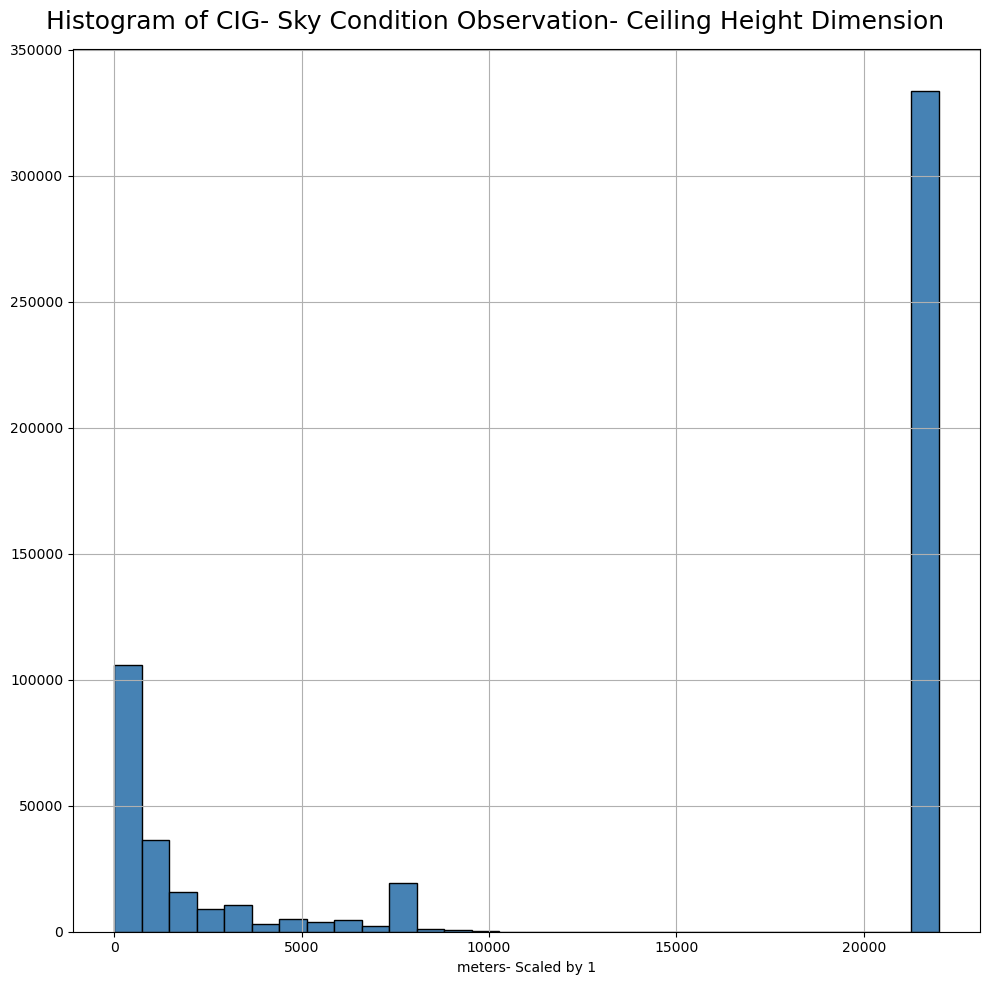

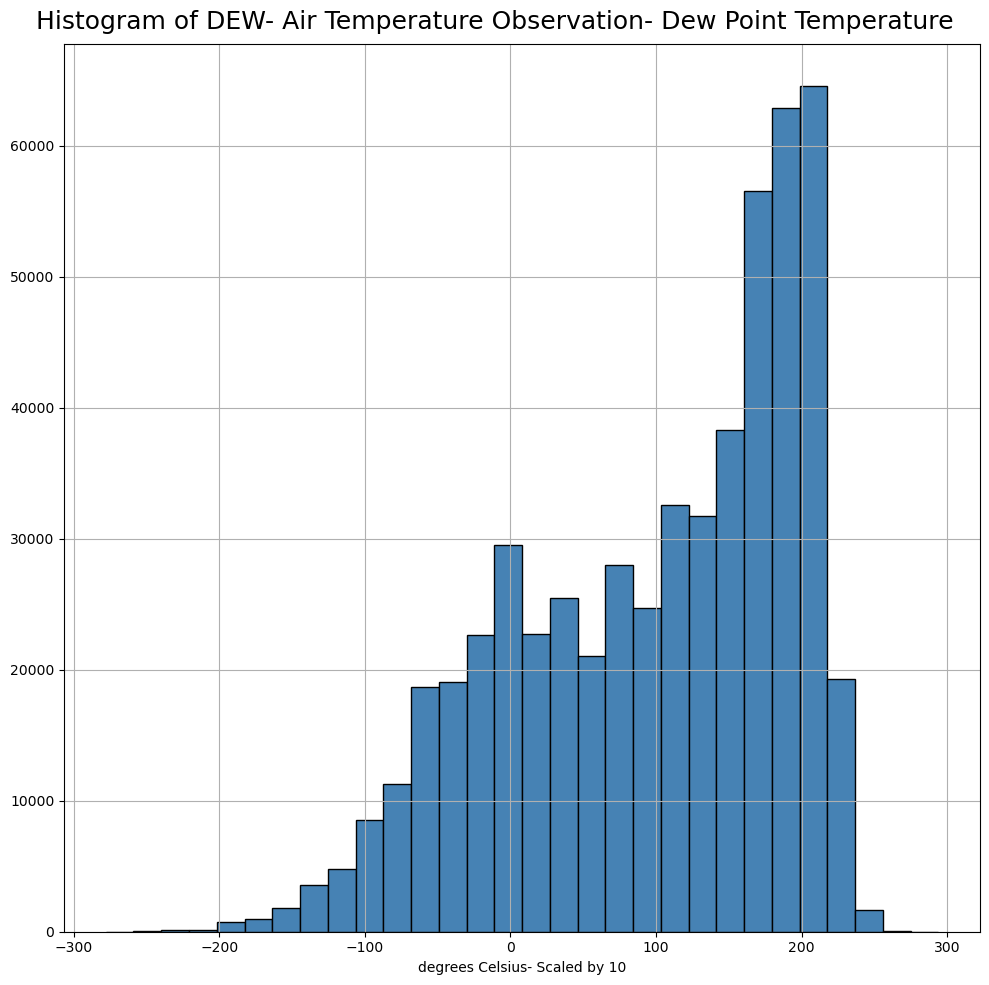

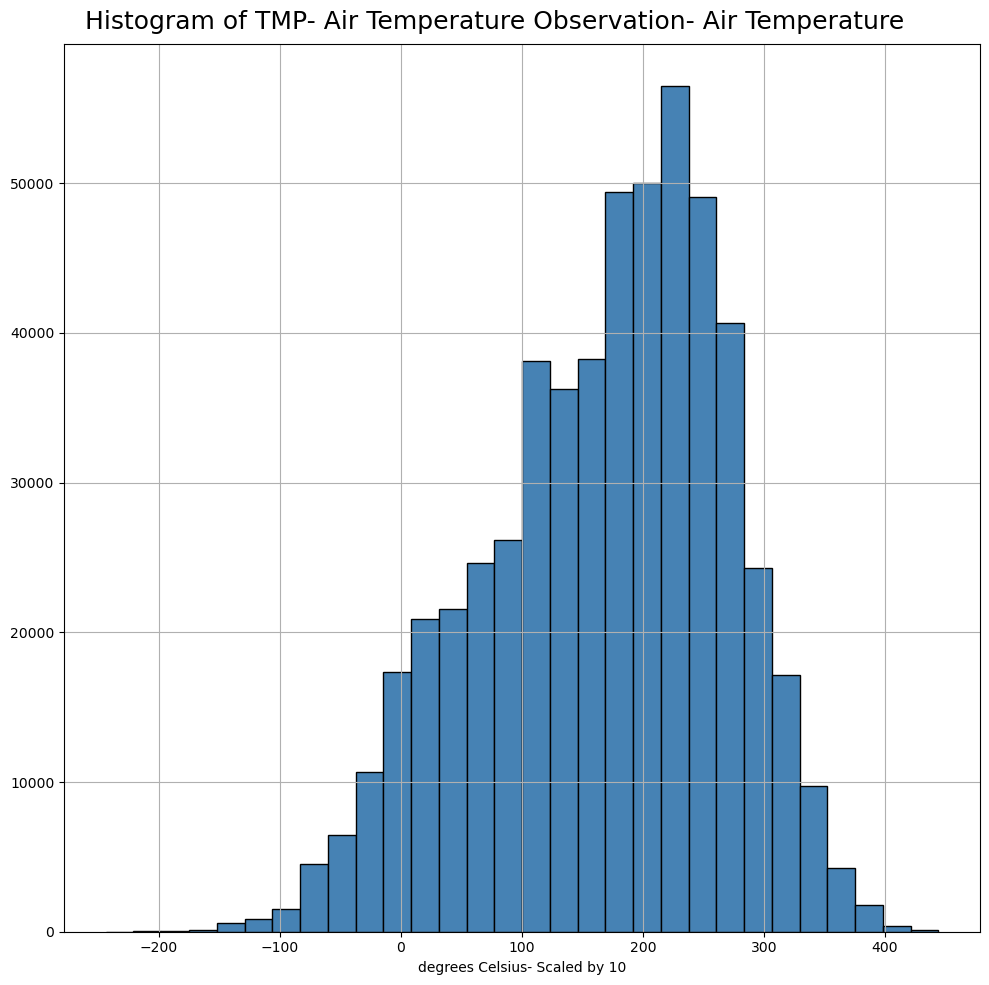

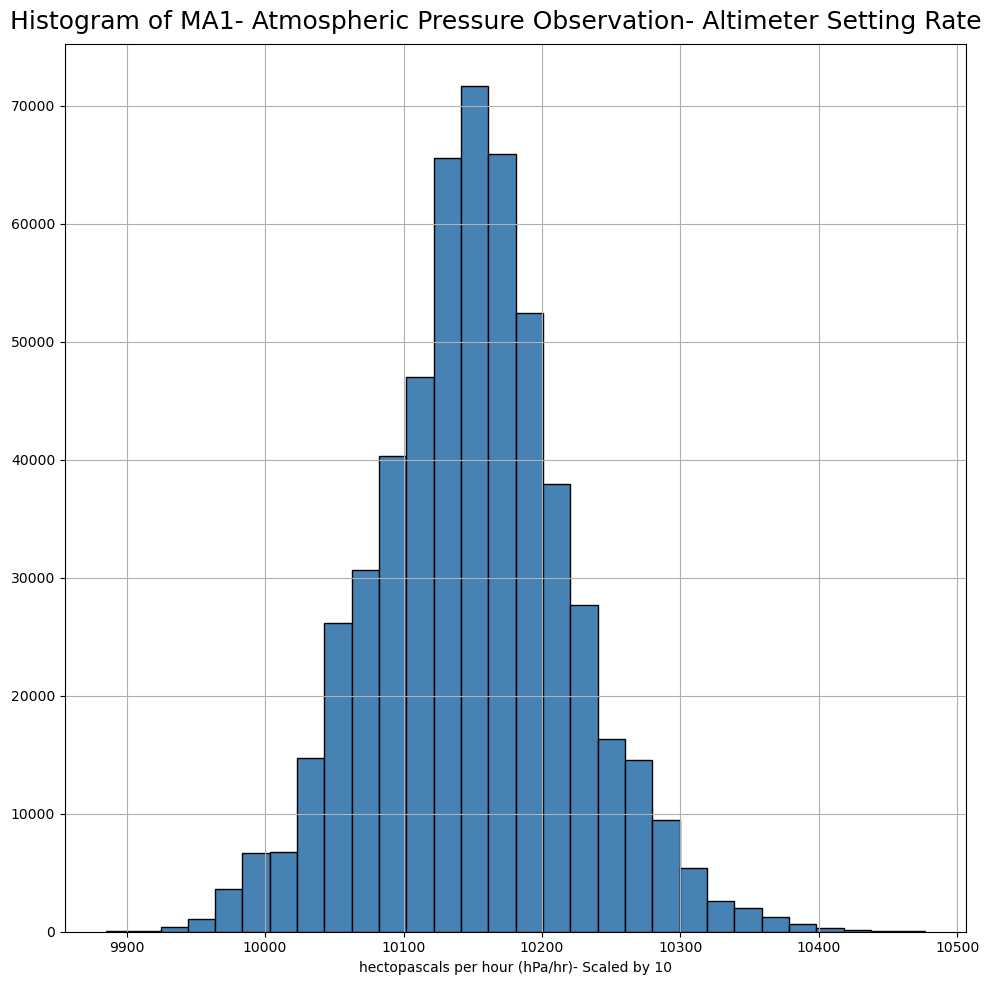

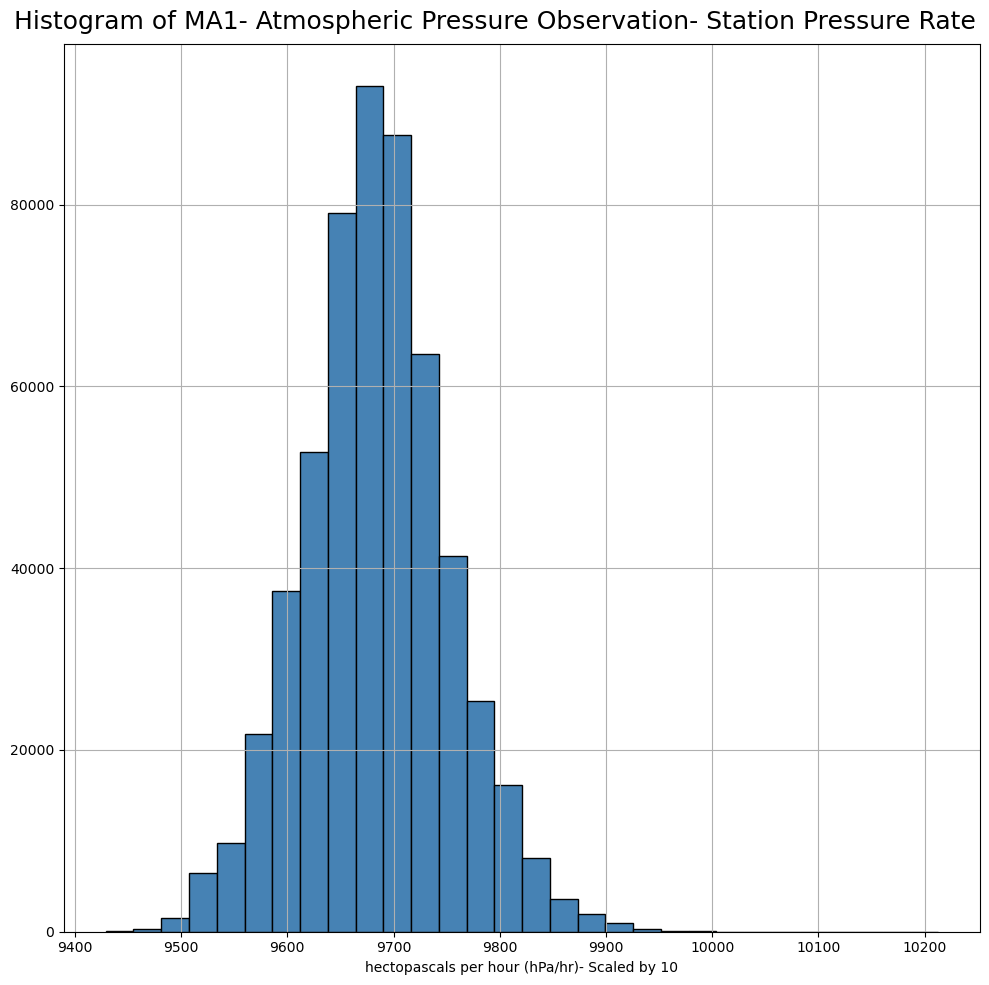

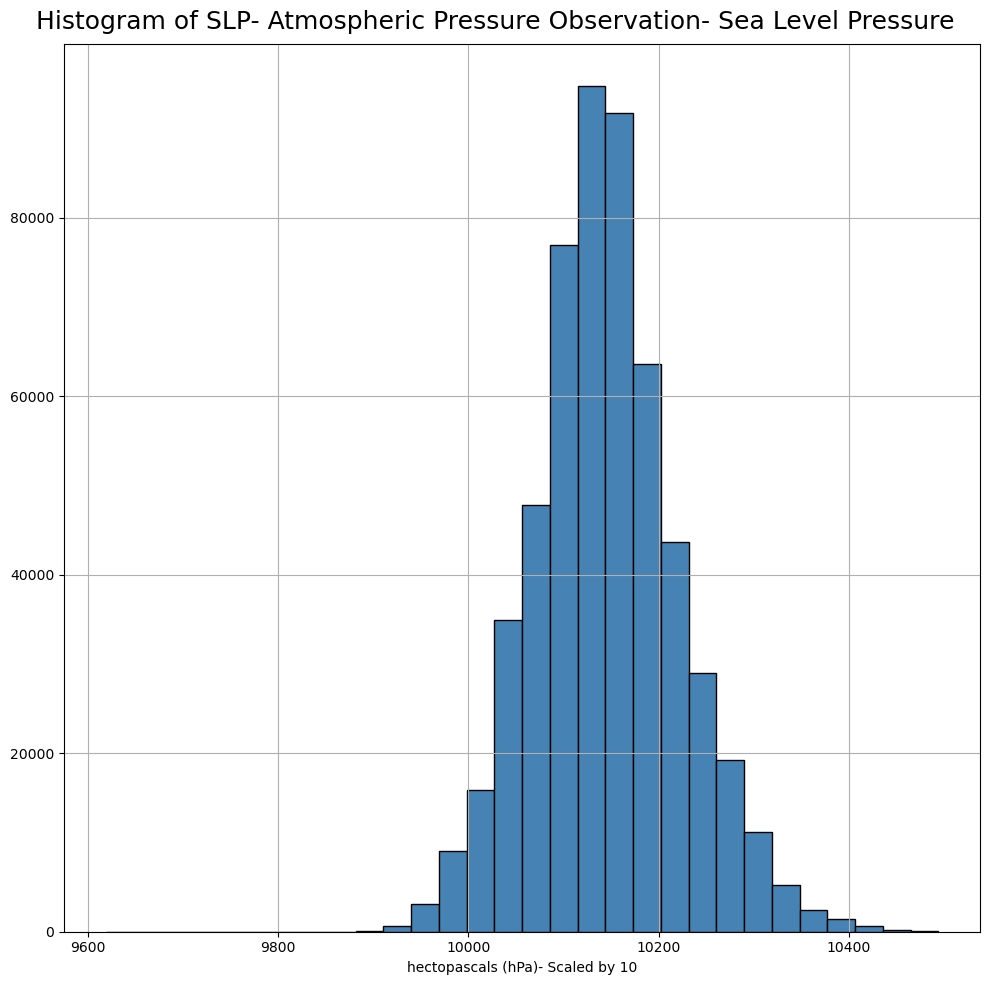

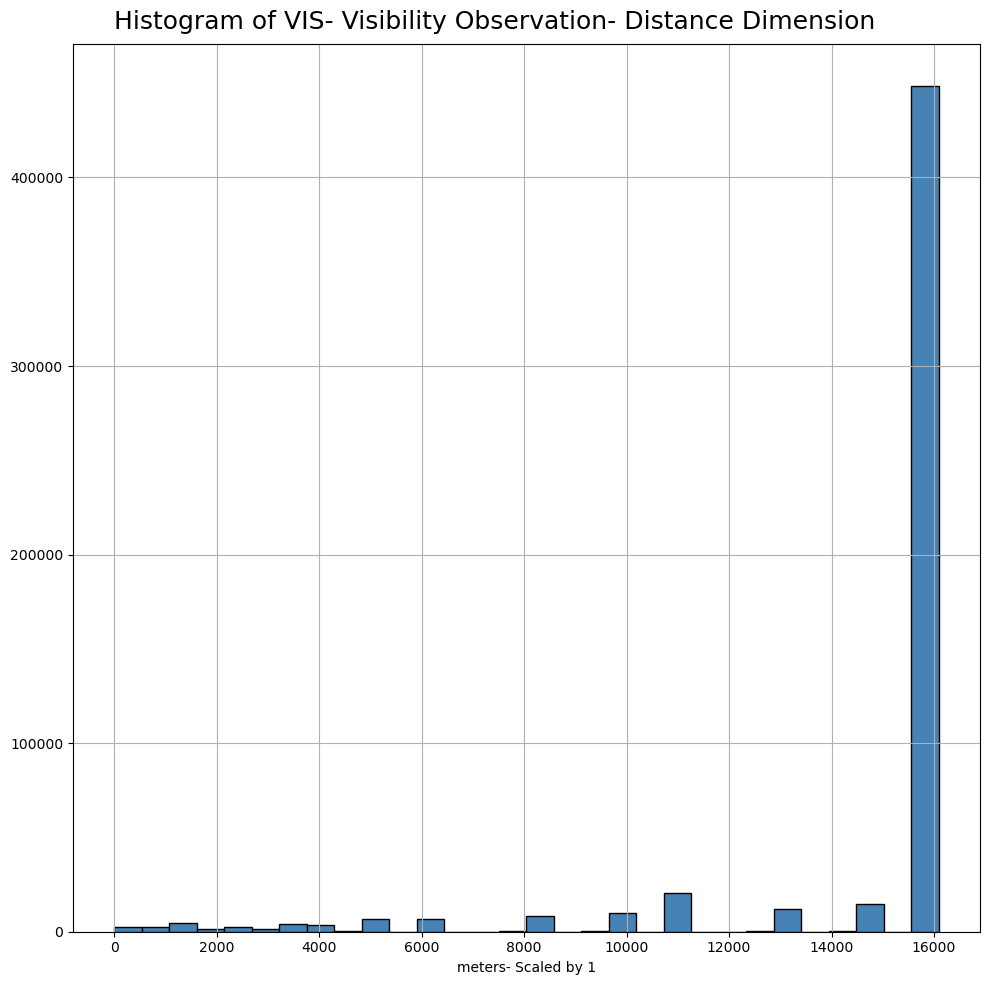

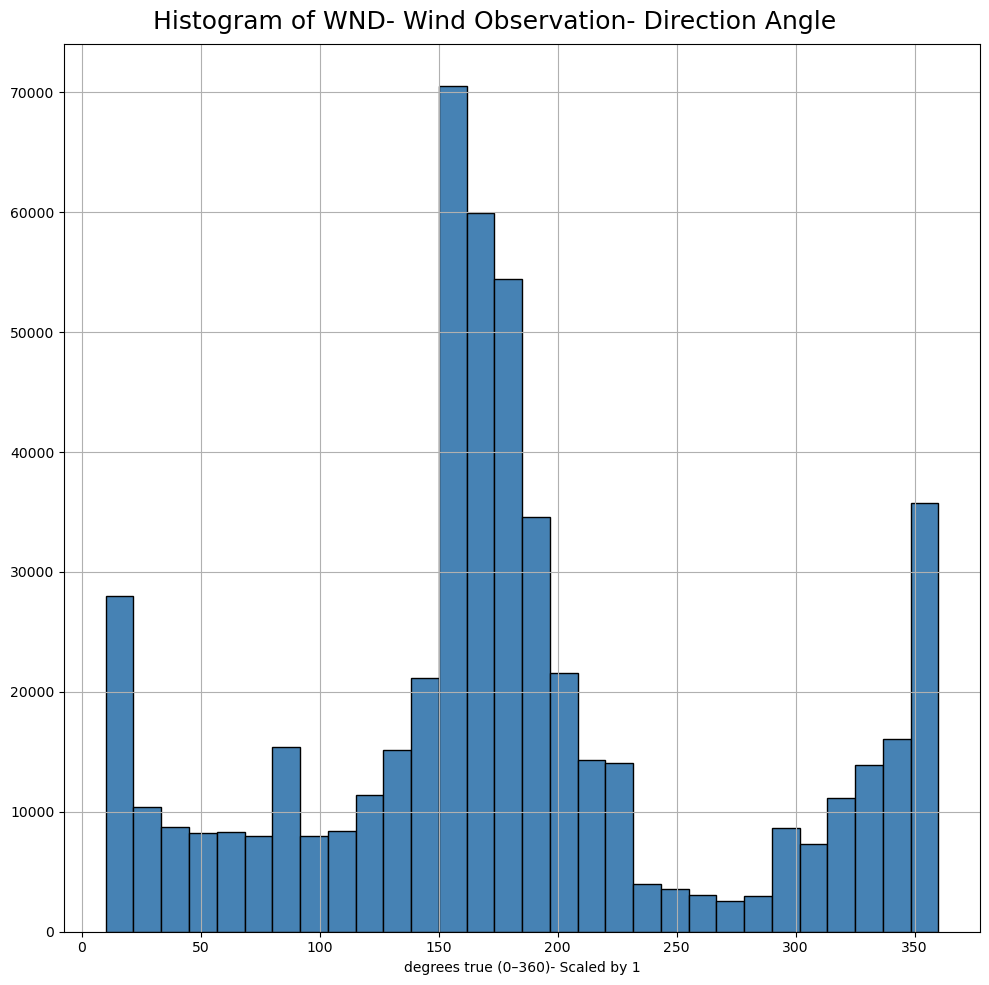

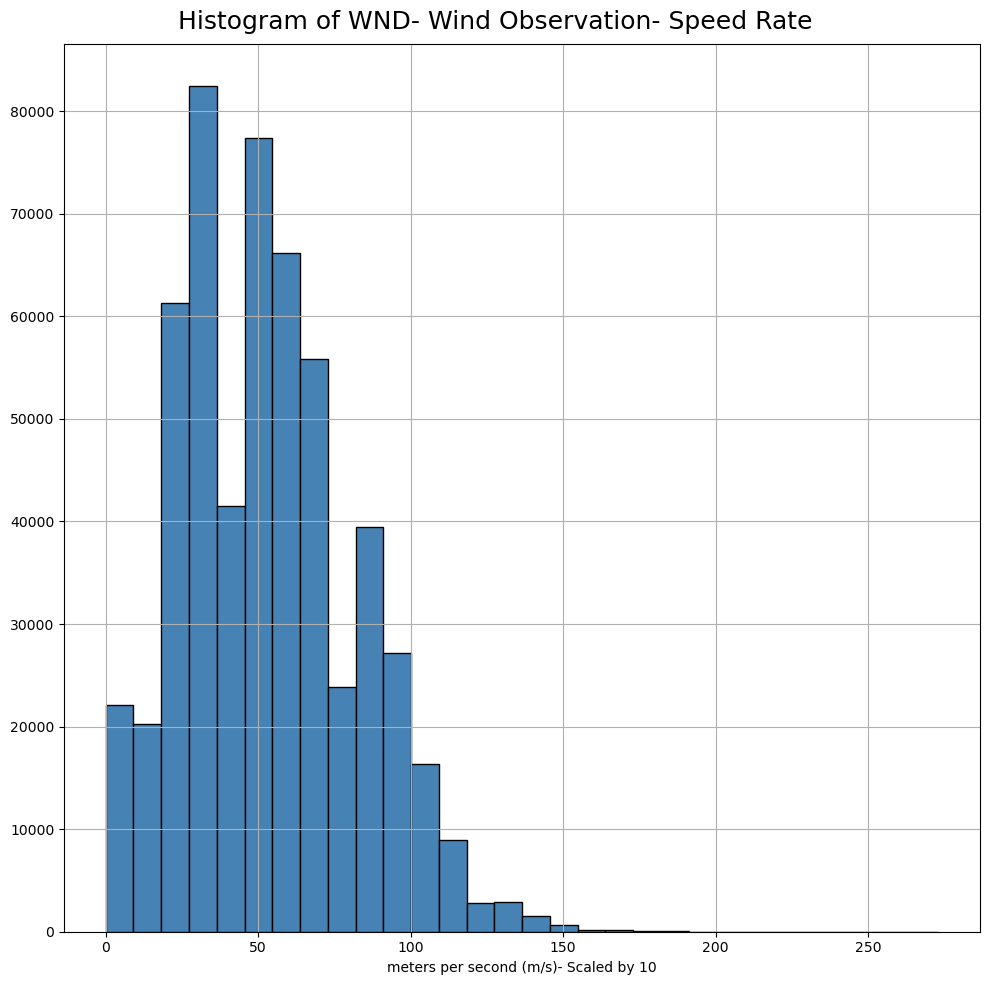

[PosixPath('/Users/taylormurray/Documents/GitHub/fall-2025-predicting-tornadoes/results/eda_figures/histograms/CIG_Ceiling_Height_Dimension_histogram.png'), PosixPath('/Users/taylormurray/Documents/GitHub/fall-2025-predicting-tornadoes/results/eda_figures/histograms/DEW_Dew_Point_Temperature_histogram.png'), PosixPath('/Users/taylormurray/Documents/GitHub/fall-2025-predicting-tornadoes/results/eda_figures/histograms/TMP_Air_Temperature_histogram.png'), PosixPath('/Users/taylormurray/Documents/GitHub/fall-2025-predicting-tornadoes/results/eda_figures/histograms/MA1_Altimeter_Setting_Rate_histogram.png'), PosixPath('/Users/taylormurray/Documents/GitHub/fall-2025-predicting-tornadoes/results/eda_figures/histograms/MA1_Station_Pressure_Rate_histogram.png'), PosixPath('/Users/taylormurray/Documents/GitHub/fall-2025-predicting-tornadoes/results/eda_figures/histograms/SLP_Sea_Level_Pressure_histogram.png'), PosixPath('/Users/taylormurray/Documents/GitHub/fall-2025-predicting-tornadoes/results

In [85]:

links = []
for col,vals in isd_float_meteor_columns.items():
    data[col].hist(
        bins=30,            # number of bins per histogram
        figsize=(10,10),   # overall figure size
        color='steelblue',  # bar color
        edgecolor='black'   # border color
    )
    plt.xlabel(f"{vals['units']}- Scaled by {vals['scale']}")
    plt.suptitle(f"Histogram of {col}", fontsize=18)
    plt.tight_layout()
    # valid names for figure paths
    path_friendly_1= col.split('-')[0].replace(' ','_')
    path_friendly_2= col.split('-')[2].replace(' ','_')
    path_friendly = path_friendly_1+path_friendly_2
    save_to_path = pathlib.Path(f"results/eda_figures/histograms/{path_friendly}_histogram.png")
    plt.savefig(project_root/save_to_path, dpi=300, bbox_inches='tight')
    plt.show()
    links.append(project_root/save_to_path)
    plt.close()

print(links)
    



#### Histogram Observations

#### [CIG — Sky Condition Observation (Ceiling Height Dimension)](<../results/eda_figures/histograms/CIG_Ceiling_Height_Dimension_histogram.png>)
The ceiling height distribution is highly bimodal and strongly asymmetric, with a dominant spike at 22,000 m, corresponding to “unlimited ceiling” or clear sky conditions in ISD standards. The secondary cluster below 2,000 m represents overcast or cloudy conditions. 
It is important to note that in handling NaN values in this feature, we did send a few to 22000 (clear skies). 

#### [DEW — Dew Point Temperature](<../results/eda_figures/histograms/DEW_Dew_Point_Temperature_histogram.png>)
The dew point histogram skewed to the right, showing most values between 0°C and 20°C (scaled ×10), with a long tail extending into subzero temperatures. The strong clustering at higher dew points indicates high moisture content for a significant number of samples— a key tornado precursor. This makes sense especially for a tornado prone state such as Oklahoma. Such heavy-tailed structure is typical in meteorological data and may benefit from log transformation before regression or classification.

#### [MA1 — Altimeter Setting Rate](<../results/eda_figures/histograms/MA1_Altimeter_Setting_Rate_histogram.png>)
Altimeter setting rates are tightly centered around 10,150 hPa/hr, forming an approximately normal distribution. The lack of skewness indicates consistent barometric conditions for each station, as expected from well-calibrated instrumentation. Variability here illustrates large-scale pressure changes across stations as opposed to day to day pressure changes.

#### [MA1 — Station Pressure Rate](<../results/eda_figures/histograms/MA1_Station_Pressure_Rate_histogram.png>)
Station pressure rates follow a slightly left-skewed, near-normal distribution centered near 9,670 hPa/hr (scaled by 10). This reflects local atmospheric pressure variations and surface elevation differences across observation sites. 

#### [SLP — Sea Level Pressure](<../results/eda_figures/histograms/SLP_Sea_Level_Pressure_histogram.png>)
Sea level pressure observations follow a slightly left-skewed, near-normal distribution centered around 10,150 hPa (scaled by 10). Minor left skew suggests slightly more frequent low-pressure readings, consistent with the stormy or unstable periods captured by the dataset. 

#### [TMP — Air Temperature](<../results/eda_figures/histograms/TMP_Air_Temperature_histogram.png>)
The temperature distribution follows a right-skewed distribution, peaking between 19°C and 25°C (scaled by 10). Lower tails extend into subfreezing temperatures, representing nighttime or winter readings. Such heavy-tailed structure is typical in meteorological data and may benefit from log transformation before regression or classification.

####  [VIS — Visibility (Distance Dimension)](<../results/eda_figures/histograms/VIS_Distance_Dimension_histogram.png>)
Visibility has a pronounced spike at around 16,000 meters, which is the ISD’s “maximum measurable visibility.” The remainder of the data declines rapidly toward lower distances, suggesting that full-visibility conditions dominate, which is too be expected. Might be worth viewing this as categorical "clear", "somewhat clear", and "not clear" rather than numerical.

#### [WND — Wind Direction Angle](<../results/eda_figures/histograms/WND_Direction_Angle_histogram.png>)
Wind direction forms a multimodal distribution, with peaks near 5° (north), 150–200° (south-southwest), and 350-360° (north-northwest). 

#### [WND — Wind Speed Rate](<../results/eda_figures/histograms/WND_Speed_Rate_histogram.png>)
Wind speed rates exhibit a left skewed distribution, with most values between 0–80 m/s (scaled ×10) and a long upper tail extending to 200+. Such heavy-tailed structure is typical in meteorological data and may benefit from log transformation before regression or classification.


### KDE Plots 

To complement the univariate histograms, the following kernel density estimates (KDEs) visualize the probability distributions of meteorological variables conditioned on tornado occurrence. These plots allow for a direct comparison of atmospheric regimes, showing where tornado-related observations deviate from background weather patterns. By contrasting densities between the two groups, we identify which environmental factors most strongly characterize tornadic environments.

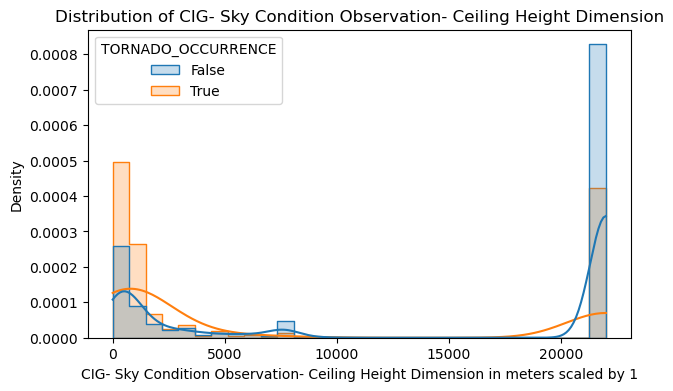

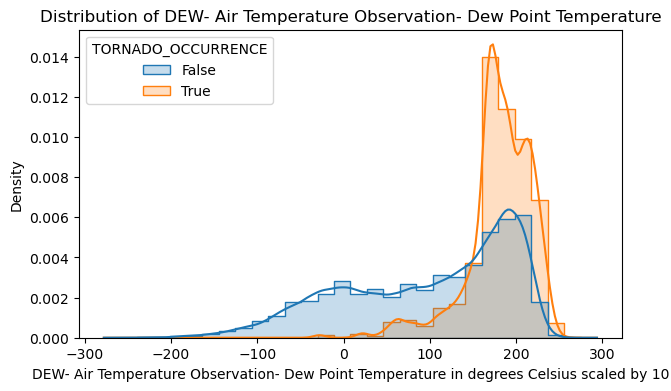

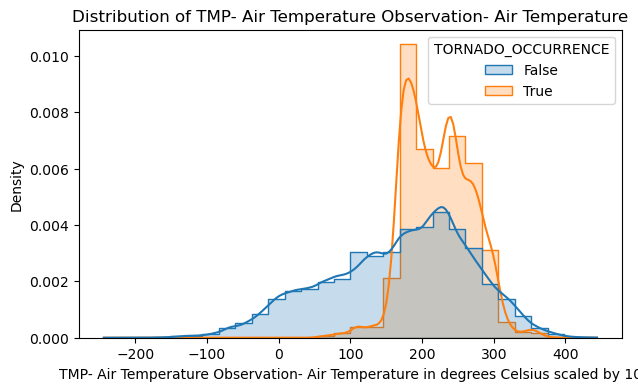

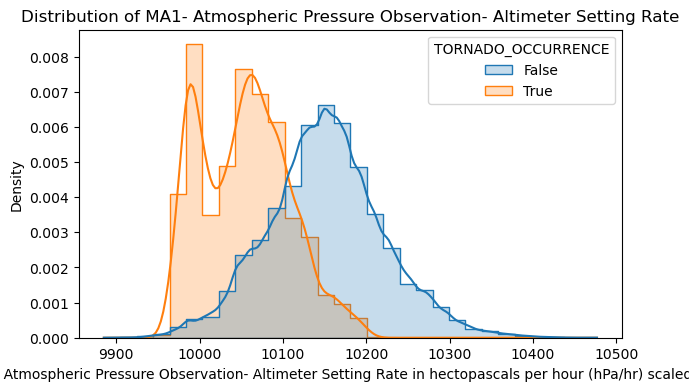

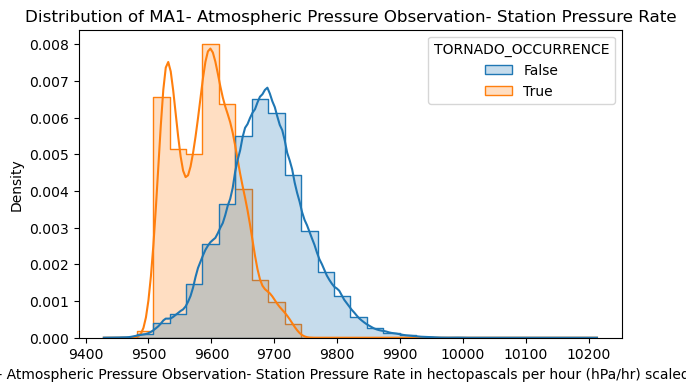

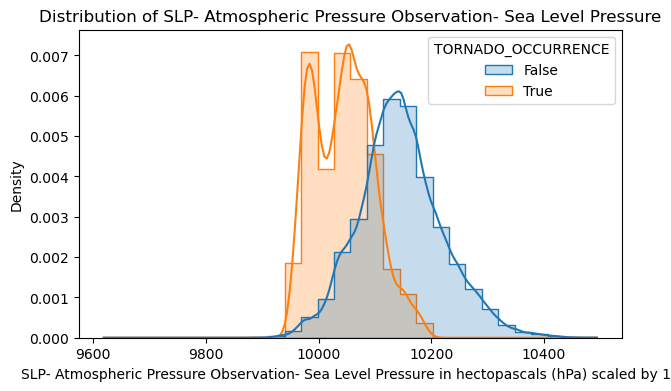

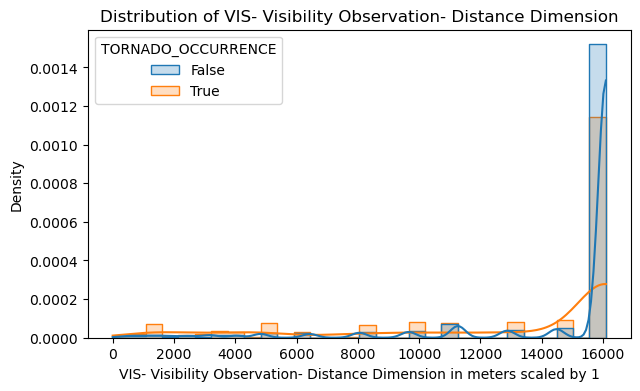

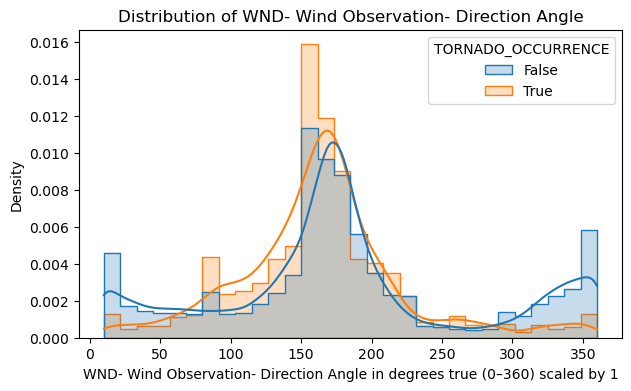

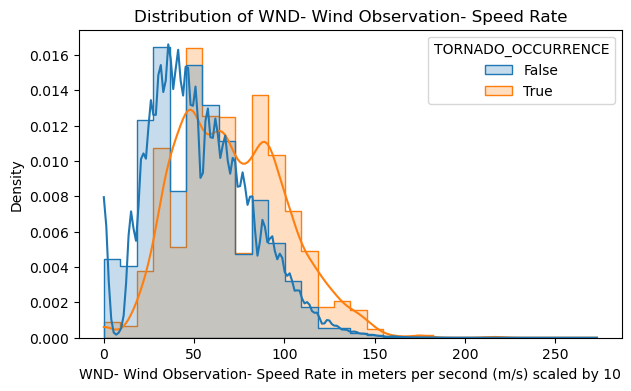

In [86]:


# Select a few weather variables to visualize


for col,vals in isd_float_meteor_columns.items():
    plt.figure(figsize=(7,4))
    sns.histplot(
        data=data,
        x=col,
        hue='TORNADO_OCCURRENCE',
        bins=30,
        kde=True,
        element='step',
        stat='density',
        common_norm=False
    )
    plt.title(f"Distribution of {col}")
    plt.xlabel(f"{col} in {vals['units']} scaled by {vals['scale']}")
    plt.ylabel("Density")
    path_friendly= col.replace('-','_').replace(' ','')
    save_to_path = pathlib.Path(f"results/eda_figures/sns_density_histograms/{path_friendly}_sns_density_hist.png")
    plt.savefig(project_root/save_to_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    plt.close()




#### [CIG — Sky Condition Observation (Ceiling Height Dimension)](<../results/eda_figures/sns_density_histograms/CIG_SkyConditionObservation_CeilingHeightDimension_sns_density_hist.png>)
The ceiling height distribution is strongly bimodal, with the non-tornado class (blue) peaking sharply at 22,000 m (clear skies). Tornado-associated observations (orange) occur  at much lower ceiling heights, indicating more frequent cloud cover or overcast conditions during tornadic environments.

**However**, an odd anomaly is that there are a significant number of tornadoes occurring when the ceiling height is 22000. Likely this is because of our NaN convention above when we set NaN values in this feature to 22000. It might be good to drop this feature before model training for this reason.

#### [DEW — Dew Point Temperature](<../rresults/eda_figures/sns_density_histograms/DEW_AirTemperatureObservation_DewPointTemperature_sns_density_hist.png>)
Tornado events cluster around higher dew point values (150–220 × 0.1 °C), in contrast with a broader, cooler distribution for non-tornado cases. 

#### [MA1 — Altimeter Setting Rate](<../results/eda_figures/sns_density_histograms/MA1_AtmosphericPressureObservation_AltimeterSettingRate_sns_density_hist.png>)
The tornado distribution skews toward lower altimeter settings, with a distinct leftward shift relative to non-tornado observations. Moreover, the non-tornado observations appear to be near-normally distributed.

#### [MA1 — Station Pressure Rate](<../results/eda_figures/sns_density_histograms/MA1_AtmosphericPressureObservation_StationPressureRate_sns_density_hist.png>)
A similar pattern emerges for station pressure as it did for the altimeter setting rate: the tornado distribution skews toward lower altimeter settings, with a distinct leftward shift relative to non-tornado observations. Moreover, the non-tornado observations appear to be near-normally distributed

#### [SLP — Sea Level Pressure](<../results/eda_figures/sns_density_histograms/SLP_AtmosphericPressureObservation_SeaLevelPressure_sns_density_hist.png>)
Again a similar pattern to the distributions for the altimeter setting rates and station pressure rates. 

#### [TMP — Air Temperature](<../results/eda_figures/sns_density_histograms/TMP_AirTemperatureObservation_AirTemperature_sns_density_hist.png>)
Air temperature distributions show that tornadoes favor warmer ambient conditions, with the orange density peaking near 170–290 (× 0.1 °C).

#### [VIS — Visibility Observation (Distance Dimension)](<../results/eda_figures/sns_density_histograms/VIS_VisibilityObservation_DistanceDimension_sns_density_hist.png>)
Visibility patterns reveal a dominance of maximum-measured values (16,000 m) for both classes. However, below the rightmost extreme the tornado distribution is more broadly distributed than its non-tornado counterpart. 

**In addition to the CIG Ceiling Height Dimensions features, this is another feature that we might consider dropping before training models.**

#### [WND — Wind Direction Angle](<../results/eda_figures/sns_density_histograms/WND_WindObservation_DirectionAngle_sns_density_hist.png>)
Both distributions are multimodal, but tornado-associated winds are  concentrated more around southerly to southwesterly directions (150–200°). Likely not a great indicator of tornadic lead-up since it is somewhat similar to the non-tornadic winds.

#### [WND — Wind Speed Rate](<../results/eda_figures/sns_density_histograms/WND_WindObservation_SpeedRate_sns_density_hist.png>)
The tornado distribution is skewed toward higher wind speeds than it's counterpart. 

#### Overall KDE Summary

Consider dropping `CIG — Sky Condition Observation (Ceiling Height Dimension)` and `VIS — Visibility Observation (Distance Dimension)` since the distribution regions of peak tornadic and non-tornadic values are very similar and do not vary largely elsewhere in the distributions.



### Boxplots with WND Type Code

We now look at boxplots with our numeric meterological features together with our categorical meterological feature `WND- Wind Observation- Type Code`.

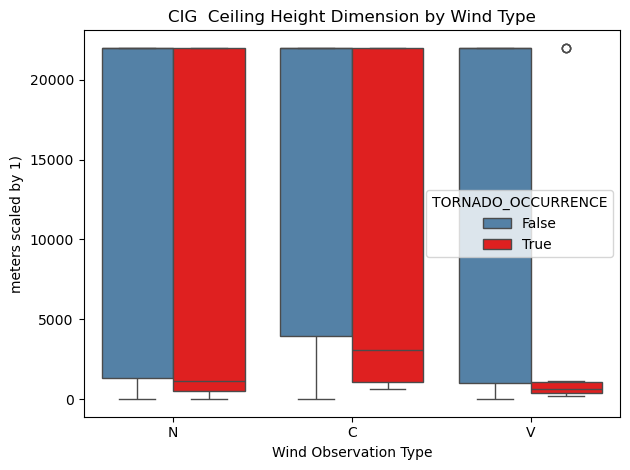

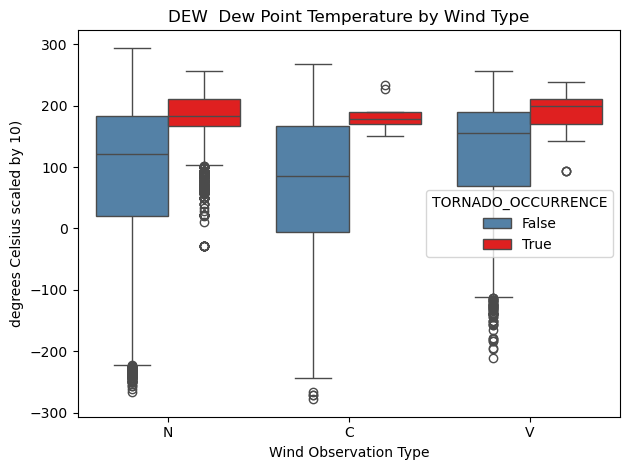

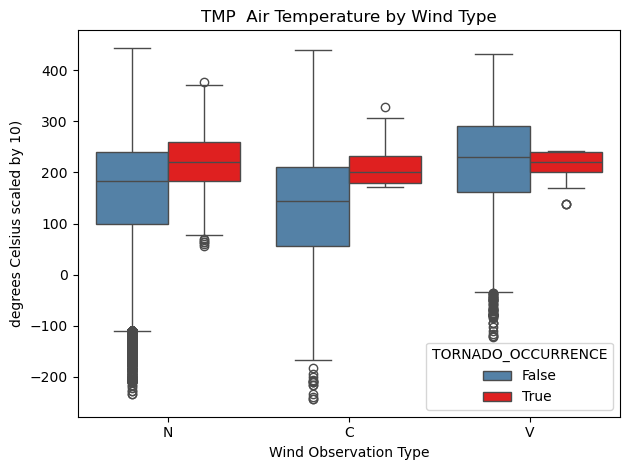

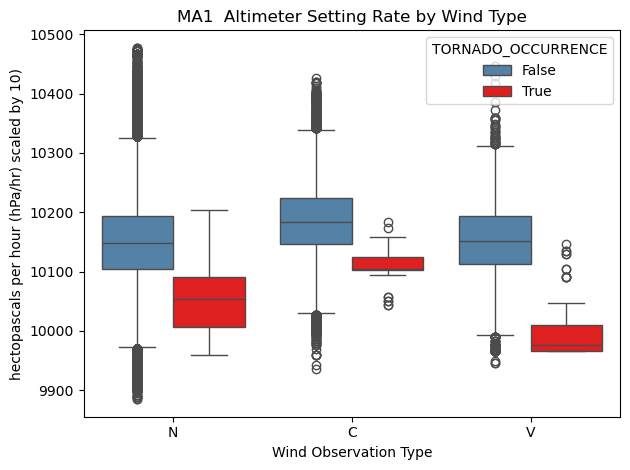

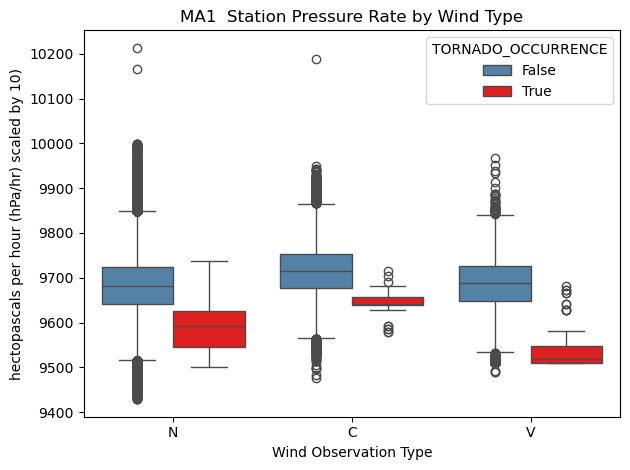

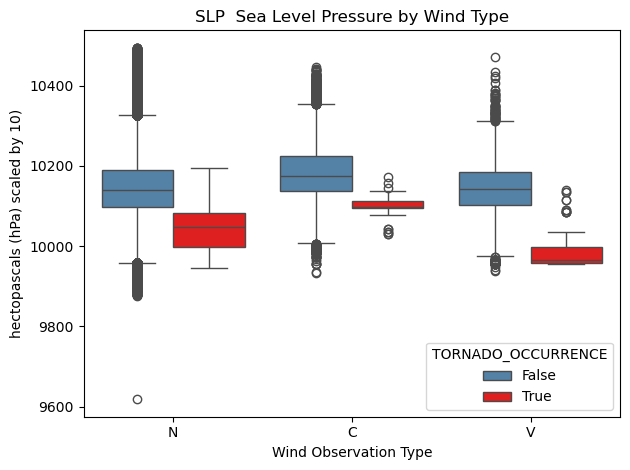

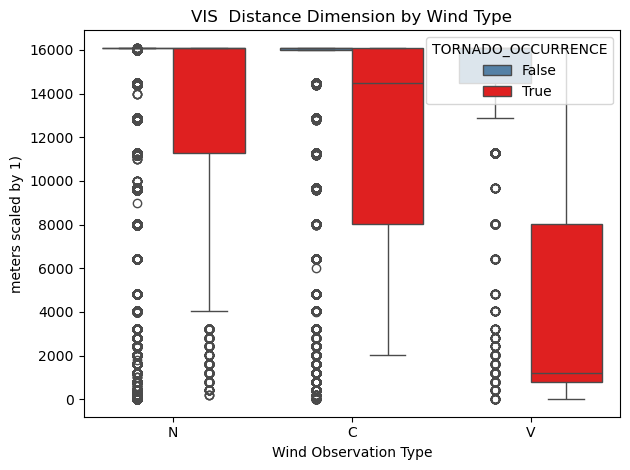

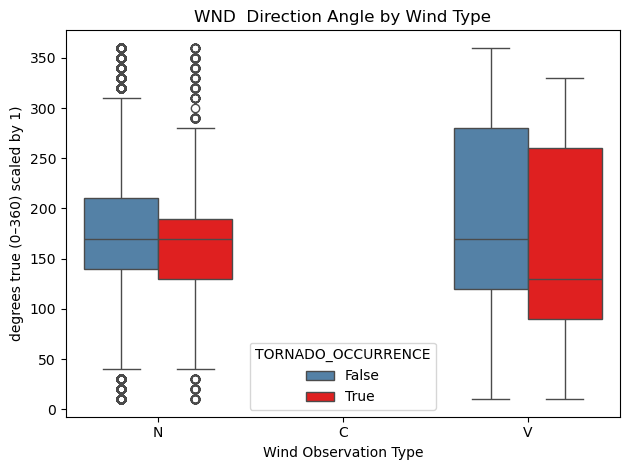

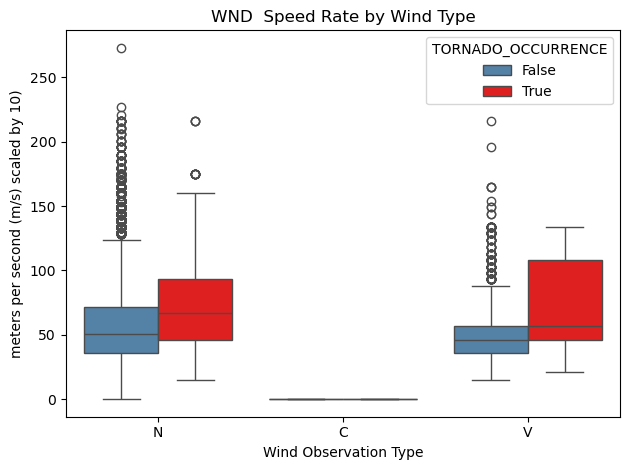

In [87]:

for col_y, vals in isd_float_meteor_columns.items():
    sns.boxplot(
        data=data,
        x='WND- Wind Observation- Type Code',
        y= col_y,
        hue='TORNADO_OCCURRENCE',
        palette={True: 'red', False: 'steelblue'}
    )
    path_friendly_1= col_y.split('-')[0].replace(' ','_')
    path_friendly_2= col_y.split('-')[2].replace(' ','_')
    path_friendly = path_friendly_1+path_friendly_2
    plt.title(f'{path_friendly_1} {path_friendly_2.replace('_',' ')} by Wind Type')
    plt.xlabel('Wind Observation Type')
    plt.ylabel(f'{vals['units']} scaled by {vals['scale']})')
    plt.tight_layout()
    save_to_path = pathlib.Path(f'results/eda_figures/boxplots/windtype_by_{path_friendly}.png')
    plt.savefig(project_root/save_to_path, dpi=300)
    plt.show()
    
    plt.close()




#### Overall Observation Summary
Across most variables, tornado occurrences are concentrated under “Normal” and "Variable". However, there are a few variables that have a non-negligible concentration of tornado occurrences under the calm category. 

Moreover, we see more reason to drop `CIG — Sky Condition Observation (Ceiling Height Dimension)` and `VIS — Visibility Observation (Distance Dimension)` before model training. The former should be dropped since there doesn't seem to be a clear distinction between tornadic and non-tornadic values. The latter should be dropped because of the extreme number of outlier that are occuring for each Wind Type code vs tornadic and non-tornadic values for the VIS Distance Dimension feature.

### Correlation Matrix

The code belows creates and displays a Pearson correlation matrix heatmap. This is key in finding variables that are highly correlated.

* The Pearson Correlation Matrix can be found here [results/eda_summaries/correlation_matrix.csv](<../results/eda_summaries/correlation_matrix.csv>).

* The displayed heatmap can be found here [results/eda_figures/correlation/correlation_heatmap.png](<r../esults/eda_figures/correlation/correlation_heatmap.png>).

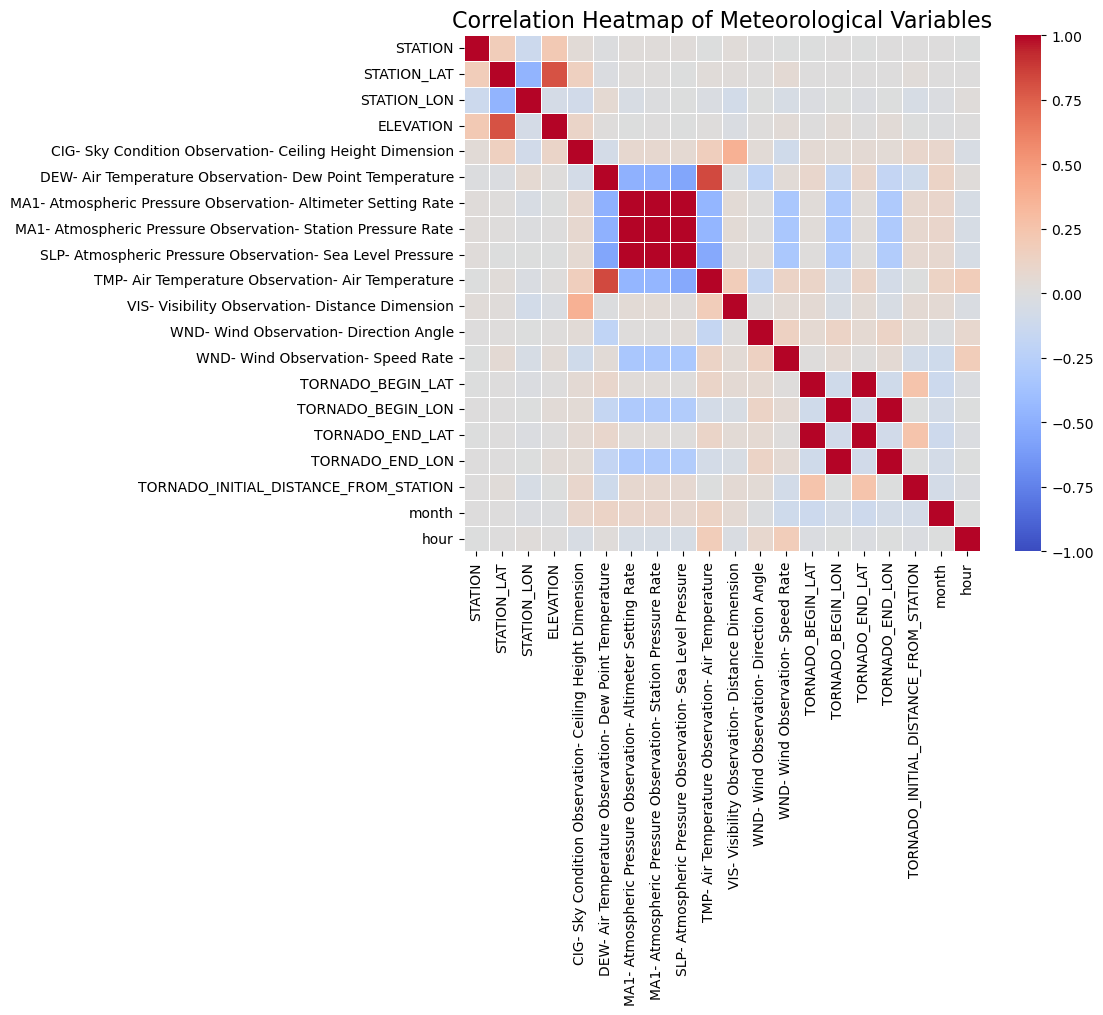

In [88]:

corr_matrix = data.select_dtypes(include=np.number).corr(method='pearson')

# Save correlation matrix to CSV
save_to_path = pathlib.Path('results/eda_summaries/correlation_matrix.csv')
corr_matrix.to_csv(project_root/save_to_path)

# Set up figure
plt.figure(figsize=(12,10))
sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    vmin=-1, vmax=1,
    center=0,
    annot=False,       # change to True if you want numbers shown
    square=True,
    linewidths=0.5
)
plt.title('Correlation Heatmap of Meteorological Variables', fontsize=16)
plt.tight_layout()

# Save figure
save_to_path = pathlib.Path('results/eda_figures/correlation/correlation_heatmap.png')
plt.savefig(project_root/save_to_path, dpi=300, bbox_inches='tight')
plt.show()

plt.close()

#### Correlation Matrix Summary

A few of the correlations:

| Feature 1                         | Feature 2                            | Corr. (r)            | Interpretation                                                                                                                                                  |
| --------------------------------- | ------------------------------------ | -------------------- | --------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **TMP — Air Temperature**         | **DEW — Dew Point Temperature**      | **≈ +0.84**          | Strong thermodynamic coupling: warmer air tends to hold more moisture, leading to higher dew points. These two features are nearly redundant for linear models. |
| **TMP - Air Temperature** | **SLP - Sea Level Pressure** |**≈ -0.54** | Mild negative correlation between temperature and sea level pressure. |
| **MA1 — Altimeter Setting Rate**  | **MA1 — Station Pressure Rate**      | **≈ +0.999**          | Both measure barometric pressure trends; extremely strong redundancy reflecting the same underlying atmospheric pressure behavior.                              |
| **MA1 — Altimeter Setting Rate**  | **SLP — Sea Level Pressure**         | **≈ +0.993**          | Sea-level pressure and station pressure are inherently linked via altitude corrections; retain one for linear models.                                           |
| **Station Latitude**              | **Station Longitude**                | **≈ -.48**          | Solely used for creating the TORNADO_OCCURRENCE column, so these will be dropped before model training.                                          |
| **Tornado Begin Latitude**        | **Tornado End Latitude**             | **≈ +0.999**          | Solely used for creating the TORNADO_OCCURRENCE column, so these will be dropped before model training.close.                                                    |
| **Tornado Begin Longitude**       | **Tornado End Longitude**            | **≈ +0.999**          | Similar solely used for creating the TORNADO_OCCURRENCE column, so these will be dropped before model training.                                                 |                                                                                        |



**Interpretation and Modeling Implications**

* Pressure variables (MA1, SLP) and thermodynamic variables (TMP, DEW) are highly collinear.
For logistic regression or linear models, drop one from each correlated pair.

* For tree-based models, these can be safely retained — the algorithm will handle redundancy, though feature importance may be split. 

* Geospatial features (LAT, LON) and TORNADO begin and end (LAT,LON) coordinate points are solely used for creating the TORNADO_OCCURRENCE column, so these will be dropped before model training.

* Cloud and visibility variables (CIG, VIS) appear moderately coupled but not predictive in isolation; this is more of a reason to drop both of these.

### Note On Scatterplots

Pairwise scatter plots were considered but ultimately omitted due to the large dataset size and the strong linear structure already summarized in the correlation matrix. The combination of univariate histograms, conditional KDEs, and categorical boxplots already provides sufficient coverage of distributional shape, separation, and potential redundancy among features. Scatter plots would add visual clutter without additional interpretive value at this scale.

### Temporal Patterns

We examine the temporal distribution of tornado occurrences, we aggregate tornado indicators by month and by hour of the day. 

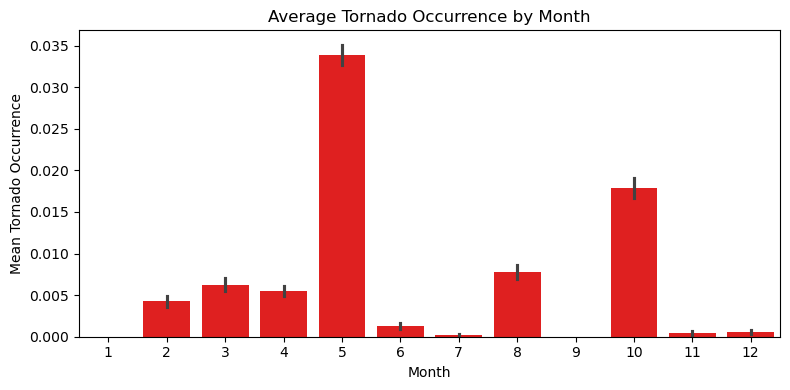

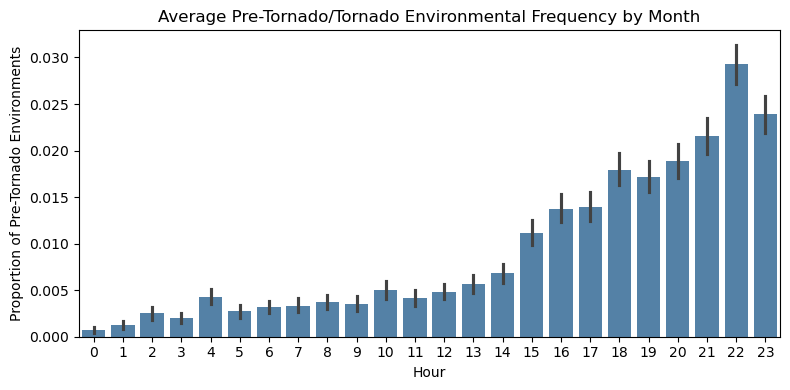

In [89]:
# Extract datetime features
data['STATION_DATE_TIME'] = pd.to_datetime(data['STATION_DATE_TIME'], errors='coerce')
data['month'] = data['STATION_DATE_TIME'].dt.month
data['hour'] = data['STATION_DATE_TIME'].dt.hour

# Tornado frequency by month
plt.figure(figsize=(8,4))
sns.barplot(
    data=data,
    x='month',
    y='TORNADO_OCCURRENCE',
    estimator=np.mean,
    color='red'
)
plt.title("Average Tornado Occurrence by Month")
plt.xlabel("Month")
plt.ylabel("Mean Tornado Occurrence")
plt.tight_layout()
save_to_path = pathlib.Path("results/eda_figures/temporal/tornado_by_month.png")
plt.savefig(project_root/save_to_path, dpi=300)
plt.show()
plt.close()

# Tornado frequency by hour
plt.figure(figsize=(8,4))
sns.barplot(
    data=data,
    x='hour',
    y='TORNADO_OCCURRENCE',
    estimator=np.mean,
    color='steelblue'
)
plt.title("Average Pre-Tornado/Tornado Environmental Frequency by Month")
plt.ylabel("Proportion of Pre-Tornado Environments")
plt.xlabel("Hour")

plt.tight_layout()
save_to_path = pathlib.Path("results/eda_figures/temporal/tornado_by_hour.png")
plt.savefig(project_root/save_to_path, dpi=300)
plt.show()
plt.close()

These patterns show us precisely what we should expect. Namely:

1. Majority of tornadoes occur in spring and in particular during the month of May. Although there is also a small peak in October.
2. Most tornadoes occur in the late afternoon 15:00 to early night 23:00. 

### Spatial Distribution

We visualize station locations and tornado-associated samples. Latitude and longitude were primarily used to engineer tornado proximity features and will be dropped before modeling.


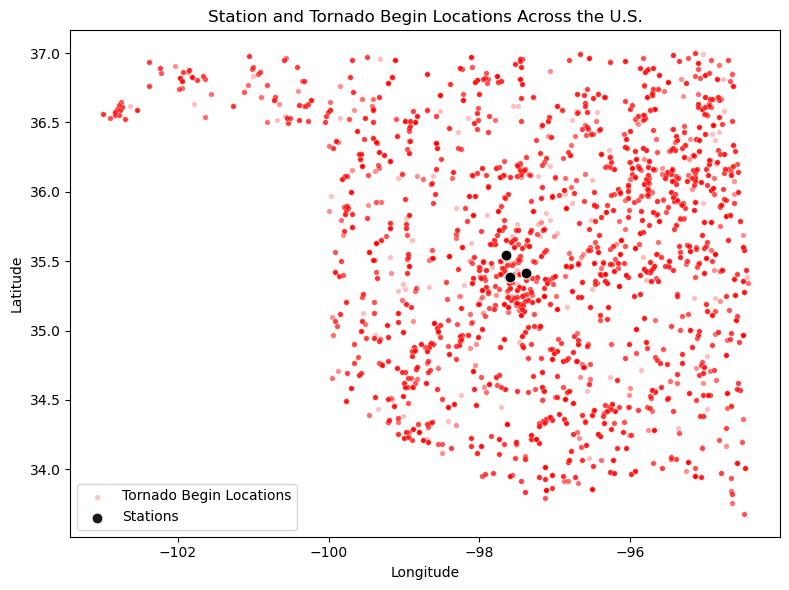

In [90]:
plt.figure(figsize=(8,6))

# Plot tornado begin locations first (fainter)
sns.scatterplot(
    data=data[~data['TORNADO_BEGIN_LAT'].isna()].sample(8000, random_state=42),
    x='TORNADO_BEGIN_LON', y='TORNADO_BEGIN_LAT',
    color='red', alpha=0.25, s=15, label='Tornado Begin Locations'
)

# Plot stations on top (larger, darker edge)
sns.scatterplot(
    data=data[['STATION_LON','STATION_LAT']].drop_duplicates(),
    x='STATION_LON', y='STATION_LAT',
    color='black', s=60, edgecolor='white', linewidth=0.7, label='Stations', alpha=0.9
)

plt.title("Station and Tornado Begin Locations Across the U.S.")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.tight_layout()
save_to_path = pathlib.Path("results/eda_figures/spatial/stations_vs_tornado_begins_highcontrast.png")
plt.savefig(project_root/save_to_path, dpi=300)
plt.show()





**Spatial Distribution Notes**

* Several stations appear visually merged. This is expected: multiple ISD stations often share nearly identical coordinates (e.g., airports, research centers, and NOAA sites within a few kilometers of one another). At this scale, stations like these will appear as a single dot.

* Overall, this spatial view validates that:
The station–tornado matching process is spatially consistent and correctly aligned.



### Tornado Occurrence (Target) Imbalance

The code below finds the frequency of each value (True and False) in the `TORNADO OCCURRENCE` column. This will guide:

* Train and Test splitting to keep the proportions of `TORNADO OCCURRENCE` values the same.

* Cross-Validation strategy to keep proportions.

* Choice of evaluation metrics. We will likely use F1-score, ROC-AUC, PR-AUC


In [91]:
# Tornado occurrence balance
tornado_counts = data['TORNADO_OCCURRENCE'].value_counts(normalize=True)
save_to_path = pathlib.Path("results/eda_summaries/tornado_counts.csv")
tornado_counts.to_csv(project_root/save_to_path)
display(tornado_counts)

TORNADO_OCCURRENCE
False    0.990856
True     0.009144
Name: proportion, dtype: float64

### Outlier Analysis

In [92]:
from scipy.stats import zscore

z_scores = np.abs(data[isd_float_meteor_columns.keys()].apply(zscore))
outlier_freq = (z_scores > 3).mean().sort_values(ascending=False)
save_to_path = pathlib.Path("results/eda_summaries/outlier_frequency.csv")
outlier_freq.to_csv(project_root/save_to_path)
outlier_freq

VIS- Visibility Observation- Distance Dimension                  0.041875
SLP- Atmospheric Pressure Observation- Sea Level Pressure        0.005035
WND- Wind Observation- Speed Rate                                0.005015
MA1- Atmospheric Pressure Observation- Station Pressure Rate     0.004318
MA1- Atmospheric Pressure Observation- Altimeter Setting Rate    0.004115
TMP- Air Temperature Observation- Air Temperature                0.001224
DEW- Air Temperature Observation- Dew Point Temperature          0.001081
CIG- Sky Condition Observation- Ceiling Height Dimension         0.000000
WND- Wind Observation- Direction Angle                           0.000000
dtype: float64

### Feature Scaling/Normality Checks


In [93]:
from scipy.stats import normaltest

for col in isd_float_meteor_columns.keys():
    stat, p = normaltest(data[col].dropna())
    print(f"{col}: p = {p:.4f}")


CIG- Sky Condition Observation- Ceiling Height Dimension: p = 0.0000
DEW- Air Temperature Observation- Dew Point Temperature: p = 0.0000
TMP- Air Temperature Observation- Air Temperature: p = 0.0000
MA1- Atmospheric Pressure Observation- Altimeter Setting Rate: p = 0.0000
MA1- Atmospheric Pressure Observation- Station Pressure Rate: p = 0.0000
SLP- Atmospheric Pressure Observation- Sea Level Pressure: p = 0.0000
VIS- Visibility Observation- Distance Dimension: p = 0.0000
WND- Wind Observation- Direction Angle: p = 0.0000
WND- Wind Observation- Speed Rate: p = 0.0000


As `p` is the probability that these samples come from a normal distribution, we conclude that each of these variables are highly non-normally distributed. This is to be expected from meteorological data. In fact, this confirms what the KDEs already suggested: these features are highly skewed, heavy-tailed, or multimodal. 

Interestingly, the histograms of some of these variables, at first glance, seemed to indicate normality. Thus, illustrating the importance of checking this with more precision.

For downstream modeling:
* Linear or logistic regression: consider transformations on these features.
* Tree-based or ensemble models: no transformation is necessary, as these algorithms are non-parametric and unaffected by non-normal feature distributions.